## **M2.958 - Anàlisi de dades en entorns Big Data - Aula 1**

## **<u>Activitat: HDFS i Batch (M4)</u>**

###  Autors
* **Nom de l'Autor 1** - Jordi Baiges Ferré
* **Nom de l'Autor 2** - Maria Serra Ruiz

### Data
* **Data:** 7 d'abril de 2026

# ![Logotip de Spark](http://spark-mooc.github.io/web-assets/images/ta_Spark-logo-small.png)

# Activitat BATCH

## Sistema de fitxers HDFS i extracció de coneixement de fonts de dades heterogènies mitjançant RDDs

En aquesta pràctica començarem amb una breu introducció a HDFS (Hadoop Distributed File System), per entendre com s'emmagatzema i distribueix la informació. Després, ens endinsarem en Spark RDDs i  Spark SQL per processar grans volums de dades de manera eficient. Per finalitzar, treballarem amb dades relacionals i la seva gestió en entorns distribuïts.

### Puntuació de l'activitat:
- **Exercici 1**: Gestió i anàlisi de dades en HDFS *(0.25 punts)*
- **Exercici 2**: Manipulació de RDDs en PySpark *(0.75 punts)*
- **Exercici 3**: Anàlisi de Dades de Tweets en PySpark *(0.75 punts)*
- **Exercici 4**: Optimització de Càlculs amb Persistència *(0.25 punts)*
- **Exercici 5**: Anàlisi de Tweets mitjançant DataFrames i consultes SQL *(1.5 punts)*
- **Exercici 6**: Anàlisi de Tweets Geolocalitzats *(1.25 punts)*
- **Exercici 7**: Anàlisi del Patró d'Activitat Horària a Twitter *(1 punts)*
- **Exercici 8**: Anàlisi de la Relació entre Tweets i Diputats per Província *(0.75 punts)*
- **Exercici 9**: Anàlisi d'Interaccions de Retweets i Graus d'Usuari *(0.5 punts)*
- **Exercici 10**: Distribució del Grau de Sortida en una Xarxa de Retweets *(0.5 punts)*
- **Exercici 11**: Preguntes teòriques *(2.5 punts)*

# **HDFS (Hadoop Distributed File System)**

<img src="https://hadoop.apache.org/docs/r1.2.1/images/hadoop-logo.jpg">

**HDFS (Hadoop Distributed File System)** és una part essencial de l'ecosistema Big Data d'Apache Hadoop. HDFS està dissenyat per emmagatzemar i gestionar grans volums de dades distribuïdes en diversos nodes d'un clúster, proporcionant alta tolerància a fallades i escalabilitat. En aquest primer exercici, interactuarem amb HDFS mitjançant la línia de comandes dins de l'entorn de **JupyterLab**, el que ens permetrà familiaritzar-nos amb les operacions bàsiques d'aquest sistema de fitxers distribuït.

Per començar, és necessari obrir un terminal des de **JupyterLab**. Un cop obert, podem enviar comandes al sistema de fitxers HDFS, que són molt similars a les comandes de bash en entorns Linux. Algunes de les comandes d'HDFS que executarem començaran amb `hdfs dfs`, seguides de l'operació que desitgem realitzar. Per exemple, si volem llistar els fitxers i directoris en el directori arrel d'HDFS, utilitzarem la comanda ls de la següent manera:

In [1]:
!hdfs dfs -ls /

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/hadoop/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/tez/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.slf4j.impl.Reload4jLoggerFactory]
Found 21 items
drwxr-xr-x   - hdfs   hdfs            0 2025-07-22 16:13 /alluxio
drwxr-xr-x   - hdfs   hdfs            0 2025-07-21 11:29 /amshbase
drwxrwxrwt   - yarn   hadoop          0 2025-11-18 13:06 /app-logs
drwxr-xr-x   - hdfs   hdfs            0 2025-07-22 12:45 /apps
drwxr-xr-x   - yarn   hadoop          0 2025-07-21 11:32 /ats
drwxr-xr-x   - hdfs   hdfs            0 2025-07-21 11:32 /atsv2
drwxr-xr-x   - sgraul hdfs            0 2025-09-24 13:49 /aula_M2.858
drwxr-xr-x   - hdfs   hdfs            0 2025-0

És important que totes les comandes s'executin correctament en l'entorn **JupyterLab** per obtenir els resultats desitjats.

Per consultar la documentació completa de les comandes disponibles en HDFS, pots accedir a la guia oficial en el següent enllaç: [HDFS Command Guide](https://hadoop.apache.org/docs/current/hadoop-project-dist/hadoop-hdfs/HDFSCommands.html)

Al llarg d'aquest exercici, utilitzarem algunes de les comandes més comunes d'HDFS per realitzar operacions com la creació de directoris, la càrrega i descàrrega d'arxius, i la gestió de permisos, entre altres. A mesura que avancem, et familiaritzaràs amb l'estructura d'HDFS i com aprofitar les seves funcionalitats en entorns Big Data.

### **Exercici 1**: Gestió i anàlisi de dades a HDFS (*0.25 punts*)

En aquest exercici treballaràs amb un conjunt de registres de consum elèctric emmagatzemats en l'arxiu `consumo_hogar_2024.csv`, disponible a la ruta /aula_M2.858/data/consumo_hogar_2024.csv.

La teva tasca consisteix a realitzar una exploració completa de l'arxiu directament a HDFS, verificant-ne la mida, permisos, propietari, factor de replicació i nombre de blocs. També hauràs de comprovar que l'arxiu no presenta errors d'integritat ni blocs danyats.

Sense descarregar completament l'arxiu, analitza la seva estructura i verifica que les dades siguin llegibles (per exemple, revisant els encapçalaments i algunes files de mostra).

Un cop confirmis que l'arxiu és correcte, crea dins del teu espai personal a HDFS una carpeta anomenada procesado a la ruta /user/[el_teu_usuari]/ i reorganitza-hi l'arxiu aplicant un nom que indiqui que ha estat validat, per exemple consumo_hogar_2024_validado.csv.

Finalment, genera un petit informe de verificació (en text pla) que resumeixi la informació principal de l'arxiu (mida, blocs, factor de replicació, propietari i data del procés) i desa'l a la mateixa carpeta procesado.

In [2]:
%%bash
# ============================================================
# EXERCICI 1 - Validació i còpia d'un arxiu a HDFS
# ============================================================

# Definir rutes d'origen i destí
SRC="/aula_M2.858/data/consumo_hogar_2024.csv"
DST_DIR="/user/jbaigesf/procesado"
DST_FILE="${DST_DIR}/consumo_hogar_2024_validado.csv"

# Definir rutes per a l'informe
REPORT_LOCAL="./informe.txt"
REPORT_HDFS="${DST_DIR}/informe.txt"

echo "===== 1. Metadades bàsiques de l'arxiu origen ====="
# Mostrar permisos, replicació, propietari, grup, mida i data de l'arxiu origen
hdfs dfs -ls "${SRC}" 2>/dev/null

echo
echo "===== 2. Comprovació de l'encapçalament i mostra de files ====="
# Mostrar capçalera i algunes files de mostra
HEAD_SAMPLE=$(hdfs dfs -cat "${SRC}" 2>/dev/null | head -n 5)
echo "${HEAD_SAMPLE}"

echo
echo "===== 3. Comprovació d'integritat de l'arxiu origen ====="
# Guardar la sortida completa de fsck de l'arxiu origen
FSCK_ORIG=$(hdfs fsck "${SRC}" -files -blocks -locations 2>/dev/null)
echo "${FSCK_ORIG}"

echo
echo "===== 4. Crear carpeta de destí a HDFS ====="
# Crear la carpeta de processament a HDFS si no existeix
hdfs dfs -mkdir -p "${DST_DIR}" 2>/dev/null

echo
echo "===== 5. Copiar i renomenar l'arxiu validat ====="
# Copiar l'arxiu origen a la carpeta de destí amb el nom requerit
hdfs dfs -cp -f "${SRC}" "${DST_FILE}" 2>/dev/null

echo
echo "===== 6. Verificació de l'arxiu copiat ====="
# Mostrar metadades bàsiques de l'arxiu copiat
DEST_LS=$(hdfs dfs -ls "${DST_FILE}" 2>/dev/null)
echo "${DEST_LS}"

echo
echo "===== 7. Comprovació d'integritat de l'arxiu copiat ====="
# Guardar la sortida completa de fsck de l'arxiu copiat
FSCK_DEST=$(hdfs fsck "${DST_FILE}" -files -blocks -locations 2>/dev/null)
echo "${FSCK_DEST}"

echo
echo "===== 8. Generar informe complet en TXT ====="

# Recuperar metadades bàsiques de l'arxiu origen
LS_LINE=$(hdfs dfs -ls "${SRC}" 2>/dev/null | tail -n 1)
PERMISOS=$(echo "${LS_LINE}" | awk '{print $1}')
REPLICACIO=$(echo "${LS_LINE}" | awk '{print $2}')
PROPIETARI=$(echo "${LS_LINE}" | awk '{print $3}')
GRUP=$(echo "${LS_LINE}" | awk '{print $4}')
MIDA=$(echo "${LS_LINE}" | awk '{print $5}')
DATA=$(echo "${LS_LINE}" | awk '{print $6, $7}')

# Extreure informació resumida de fsck
STATUS=$(echo "${FSCK_DEST}" | grep "Status:" | head -n 1 | sed 's/^[[:space:]]*//')
DATA_NODES=$(echo "${FSCK_DEST}" | grep "Number of data-nodes:" | head -n 1 | sed 's/^[[:space:]]*//')
RACKS=$(echo "${FSCK_DEST}" | grep "Number of racks:" | head -n 1 | sed 's/^[[:space:]]*//')
TOTAL_BLOCKS=$(echo "${FSCK_DEST}" | grep "Total blocks (validated):" | head -n 1 | sed 's/^[[:space:]]*//')
MISSING_BLOCKS=$(echo "${FSCK_DEST}" | grep "Missing blocks:" | head -n 1 | sed 's/^[[:space:]]*//')
CORRUPT_BLOCKS=$(echo "${FSCK_DEST}" | grep "Corrupt blocks:" | head -n 1 | sed 's/^[[:space:]]*//')
MISSING_REPLICAS=$(echo "${FSCK_DEST}" | grep "Missing replicas:" | head -n 1 | sed 's/^[[:space:]]*//')
DEFAULT_REPL=$(echo "${FSCK_DEST}" | grep "Default replication factor:" | head -n 1 | sed 's/^[[:space:]]*//')
AVG_REPL=$(echo "${FSCK_DEST}" | grep "Average block replication:" | head -n 1 | sed 's/^[[:space:]]*//')
HEALTHY_LINE=$(echo "${FSCK_DEST}" | grep "The filesystem under path" | tail -n 1)



===== 1. Metadades bàsiques de l'arxiu origen =====
-rw-r--r--   3 martam hdfs        711 2025-10-20 09:28 /aula_M2.858/data/consumo_hogar_2024.csv

===== 2. Comprovació de l'encapçalament i mostra de files =====
﻿fecha,hora,id_hogar,consumo_kwh,temperatura_ext,region
2024-01-01,00:00,H001,1.23,8.2,Madrid
2024-01-01,01:00,H001,1.15,7.9,Madrid
2024-01-01,00:00,H002,0.95,9.1,Barcelona
2024-01-01,01:00,H002,0.88,8.7,Barcelona

===== 3. Comprovació d'integritat de l'arxiu origen =====
FSCK started by jbaigesf (auth:SIMPLE) from /172.17.58.200 for path /aula_M2.858/data/consumo_hogar_2024.csv at Tue Apr 07 21:18:20 CEST 2026

/aula_M2.858/data/consumo_hogar_2024.csv 711 bytes, replicated: replication=3, 1 block(s):  OK
0. BP-1495504404-172.17.58.6-1753086652608:blk_1073760312_19539 len=711 Live_repl=3  [DatanodeInfoWithStorage[172.17.58.6:50010,DS-94d61690-8bae-419c-8424-c5e44bf76713,DISK], DatanodeInfoWithStorage[172.17.58.200:50010,DS-269ffbda-b619-40ff-8bb8-b8d6d7acfd8a,DISK], DatanodeIn

# **Apache Spark RDDs (Resilient Distributed Datasets)**

En el marc del processament de grans volums de dades amb Apache Spark, els RDDs, o Resilient Distributed Datasets, juguen un paper fonamental. Un RDD és una col·lecció d'elements que es distribueixen a través d'un clúster de nodes i sobre la qual es poden aplicar operacions que s'executen en paral·lel.

Recordem les seves característiques:

- Immutabilitat: Un cop es crea un RDD, no es pot modificar. En lloc d'això, qualsevol operació que modifiqui les dades generarà un nou RDD.

- Distribució: Els RDDs estan repartits entre els diferents nodes del clúster, permetent un processament paral·lel eficient.

- Tolerància a Fallades: Els RDDs són resistents a fallades. En cas que un node falli, Spark pot reconstruir les dades perdudes a partir de les dades originals i les operacions realitzades.

Aquesta estructura permet un processament eficient i escalable de dades, cosa que és essencial per treballar amb grans volums d'informació en entorns de clúster.

A continuació es mostra el codi que heu d'executar per configurar el vostre entorn de Spark.

> Com a referència a tots els mètodes que es requereixen per implementar aquesta pràctica podeu consultar:
> * [API Python de Spark](https://archive.apache.org/dist/spark/docs/2.4.0/api/python/index.html)

### Configuració de l'entorn python + spark

In [3]:
import findspark
import os

SPARK_HOME_PATH = "/usr/bigtop/current/spark-client/" 
os.environ['SPARK_HOME'] = SPARK_HOME_PATH
findspark.init(SPARK_HOME_PATH)

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ActividadRDDs_usuario") \
    .master("local[*]") \
    .getOrCreate()

print(spark.sparkContext.appName)
print(spark.version)

sc=spark.sparkContext

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/log4j-slf4j-impl-2.17.2.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/hadoop/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/tez/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.apache.logging.slf4j.Log4jLoggerFactory]


:: loading settings :: url = jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/jbaigesf/.ivy2/cache
The jars for the packages stored in: /home/jbaigesf/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-59cddf54-73b0-43f2-a18e-8898959a1019;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.3.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.3.0 in central
	found org.apache.kafka#kafka-clients;2.8.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.8.4 in central
	found org.slf4j#slf4j-api;1.7.32 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.2 in central
	found org.spark-project.spark#unused;1.0.0 in central
	found org.apache.hadoop#hadoop-client-api;3.3.2 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central
:: 

ActividadRDDs_usuario
3.3.4


### **Ejercicio 2**: Manipulación de RDDs en PySpark (*0.75 puntos*)

En aquest exercici, et proporcionem dues llistes de nombres en les quals realitzaràs diverses operacions sobre elles utilitzant RDDs en PySpark. La solució i l’enfocament queden al teu criteri.

Context:

Tens dues llistes de nombres que representen dades de sensors:
- **Sensor A**: Nombres de l’1 al 25.
- **Sensor B**: Nombres del 15 al 35.

Has de crear RDDs a partir de les llistes de nombres de cada sensor. Un cop fet això, per al **Sensor A**, transforma cada nombre en una tupla `(nombre, nombre al cub)` i filtra només aquells nombres el cub dels quals sigui **múltiple de 7** i **major que 50**. L’RDD resultant s’emmagatzemarà en una variable anomenada `rdd_a_filtrado`. Finalment, agrupa els nombres filtrats segons si són **parells, senars o múltiples de 5** (un nombre pot pertànyer a més d’un grup), i desa aquest resultat en `rdd_a_grupos`.

Tornant als RDDs inicials, calcula la intersecció entre els RDDs de **Sensor A i Sensor B**, desa’l en `rdd_interseccion` i calcula la diferència de **Sensor B menys Sensor A**, que es desarà en `rdd_diferencia`. A continuació, realitza una unió d’ambdós RDDs, eliminant els valors duplicats i ordenant-los de major a menor, desant el resultat en `rdd_union`.

- Imprimeix els resultats de cadascuna de les operacions realitzades utilitzant el mètode `collect()`.


In [4]:
# Crear les llistes de sensors
sensor_a = list(range(1, 26))   # 1 al 25
sensor_b = list(range(15, 36))  # 15 al 35

# Crear RDDs
rdd_a = sc.parallelize(sensor_a)
rdd_b = sc.parallelize(sensor_b)

# Sensor A: transformar a tupla (nombre, cub) i filtrar cubs múltiples de 7 i majors que 50
rdd_a_filtrado = rdd_a.map(lambda x: (x, x**3)) \
                       .filter(lambda t: t[1] % 7 == 0 and t[1] > 50)

print("rdd_a:", rdd_a.collect())
print("rdd_b:", rdd_b.collect())
print("rdd_a_filtrado:", rdd_a_filtrado.collect())

# Agrupar per parells, senars o múltiples de 5
def classificar(tupla):
    nombre, cub = tupla
    grups = []
    if nombre % 2 == 0:
        grups.append(("parells", (nombre, cub)))
    if nombre % 2 != 0:
        grups.append(("senars", (nombre, cub)))
    if nombre % 5 == 0:
        grups.append(("multiples_de_5", (nombre, cub)))
    return grups

rdd_a_grupos = rdd_a_filtrado.flatMap(classificar).groupByKey().mapValues(list)
"""
després de flatMap, és una cosa així:

[
  ("senars", (7, 343)),
  ("parells", (14, 2744)),
  ("senars", (21, 9261))
]

Per què groupByKey(): Perquè volem agrupar tots els valors que tenen la mateixa clau.

Sense groupByKey(), tindríeu registres separats:

("senars", (7,343))
("senars", (21,9261))

Amb groupByKey(), Spark els reuneix sota la mateixa clau:

("senars", <iterable amb (7,343) i (21,9261)>)
("parells", <iterable amb (14,2744)>)

"""

print("rdd_a_grupos:")
for grup, valors in rdd_a_grupos.collect():
    print(f"  {grup}: {valors}")

# Intersecció
rdd_interseccion = rdd_a.intersection(rdd_b)
print("rdd_interseccion:", sorted(rdd_interseccion.collect()))

# Diferència: Sensor B menys Sensor A
rdd_diferencia = rdd_b.subtract(rdd_a)
print("rdd_diferencia:", sorted(rdd_diferencia.collect()))

# Unió, sense duplicats, de major a menor
rdd_union = rdd_a.union(rdd_b).distinct().sortBy(lambda x: x, ascending=False)
print("rdd_union:", rdd_union.collect())


rdd_a: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
rdd_b: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


rdd_a_filtrado: [(7, 343), (14, 2744), (21, 9261)]
rdd_a_grupos:
  senars: [(7, 343), (21, 9261)]
  parells: [(14, 2744)]


rdd_interseccion: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
rdd_diferencia: [26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
rdd_union: [35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]


In [5]:
# DO NOT USE THIS CELL

### **Ejercicio 3**: Anàlisi de Dades de Tweets en PySpark (*0.75 punts*)

En aquest exercici, treballaràs amb un fitxer JSON anomenat `tweets_sample.json` que es troba a la ruta `/aula_M2.858/data/tweets_sample.json`. Aquest fitxer conté dades de tweets i mètriques relacionades. Hauràs d’utilitzar PySpark per realitzar una anàlisi de les dades. L’estructura del fitxer JSON inclou informació com el nombre de retweets, likes, seguidors i més. Tot i això, per a aquest exercici, et centraràs a processar i analitzar el contingut textual dels tweets.

- Carrega el fitxer JSON en un RDD utilitzant el mètode `textFile()`. Examina l’estructura de les dades per identificar com extreure el contingut rellevant.

- Extreu el camp tweets de cadascun dels tweets. Defineix i aplica una funció per netejar el text. Aquesta funció ha d’eliminar la puntuació, convertir el text a minúscules i assegurar que hi hagi un únic espai entre les paraules.

- Divideix el text en paraules i filtra les paraules per quedar-te amb aquelles que tinguin menys de 7 caràcters. Després, realitza un recompte de paraules diferents i desa’l a la variable `palabras_distintas_rdd`.

- Finalment, troba les 5 paraules més freqüents que acabin en vocal. Desa-ho a la variable `top_5_palabras`.

- Imprimeix els resultats de cadascuna de les operacions realitzades.

In [6]:
# Importem llibreries
import json
import re

# 1) Carregar el fitxer JSON com a RDD de línies, el fitxer és troba dins de l'espai d'arxius HDFS
tweets_raw = sc.textFile("/aula_M2.858/data/tweets_sample.json")

print("Nombre de línies del fitxer:", tweets_raw.count())
print("\nMostra de 3 línies del JSON:")
for linia in tweets_raw.take(3):
    print(linia[:300])


# 2) Funció per extreure el text del tweet
# L'enunciat diu "camp tweet".

def extreu_text(linia):
    try:
        obj = json.loads(linia)
        return obj.get("tweet")
    except:
        return "" # retornem una cadena


# 3) Funció de neteja del text
def neteja_text(text):
    text = text.lower()                              # minúscules
    text = re.sub(r"[^\w\sàèéíïòóúü]", " ", text)   # treure puntuació
    text = re.sub(r"\s+", " ", text).strip()        # un únic espai
    return text


# 4) Extreure i netejar el text
texts_rdd = (
    tweets_raw
    .map(extreu_text)  # extraiem
    .filter(lambda t: t != "")   # filtrem
    .map(neteja_text)  # netegem
)

print("\nMostra de textos nets:")
print(texts_rdd.take(5))


# 5) Separar en paraules i filtrar paraules amb menys de 7 caràcters
paraules_rdd = (
    texts_rdd
    .flatMap(lambda t: t.split(" "))
    .filter(lambda p: p != "" and len(p) < 7)
)

print("\nMostra de paraules filtrades:")
print(paraules_rdd.take(20))


# 6) Recompte de paraules diferents
palabras_distintas_rdd = (
    paraules_rdd
    .map(lambda p: (p, 1))  # transforma cada paraula en una tupla (paraula, 1)
    .reduceByKey(lambda a, b: a + b)  # suma tots els 1 que tenen la mateixa clau.
)

print("\nNombre de paraules diferents:", palabras_distintas_rdd.count())
print("Mostra del recompte:")
print(palabras_distintas_rdd.take(20))


# 7) Top 5 paraules més freqüents que acaben en vocal
vocals = ("a", "e", "i", "o", "u", "à", "è", "é", "í", "ï", "ò", "ó", "ú", "ü")

top_5_palabras = (
    palabras_distintas_rdd   # Tuples de paraules com [("hola", 3), ("mundo", 2), ("datos", 1), ("día", 2)],  x[0] = la paraula, x[1] = el nombre de vegades que apareix
    .filter(lambda x: x[0].endswith(vocals))  # filtra només les tuples on la paraula acaba en una vocal.
    .takeOrdered(5, key=lambda x: (-x[1], x[0]))  # agafa els 5 primers elements segons un criteri d’ordre. ordena segons la clau indicada i retorna només els 5 primers
)

print("\nTop 5 paraules més freqüents acabades en vocal:")
print(top_5_palabras)

Nombre de línies del fitxer: 10

Mostra de 3 línies del JSON:
{"tweet_id": 1, "user": "usuario1", "followers": 150, "retweets": 5, "likes": 10, "tweet": "¡Hola mundo! Este es un tweet de prueba para ver cómo funciona. #prueba #mundo"}
{"tweet_id": 2, "user": "usuario2", "followers": 300, "retweets": 2, "likes": 7, "tweet": "Los datos son el nuevo petróleo. Analiza, visualiza y actúa. #data #análisis"}
{"tweet_id": 3, "user": "usuario3", "followers": 500, "retweets": 15, "likes": 20, "tweet": "Un día productivo en la oficina. ¿Alguna vez has tenido un día así? #productividad"}

Mostra de textos nets:
['hola mundo este es un tweet de prueba para ver cómo funciona prueba mundo', 'los datos son el nuevo petróleo analiza visualiza y actúa data análisis', 'un día productivo en la oficina alguna vez has tenido un día así productividad', 'sabías que python es uno de los lenguajes de programación más utilizados python programación', 'la programación puede ser divertida y emocionante no te rinda

In [7]:
# DO NOT USE THIS CELL

### **Exercici 4**: Optimització de Càlculs amb Persistència (*0.25 punts*)

Per reduir els temps d'execució en Spark, és fonamental utilitzar la persistència d'un RDD mitjançant el mètode `persist()`. Aquesta tècnica és particularment útil quan es realitzen múltiples operacions repetides sobre un mateix RDD.

Quan persisteixes un RDD, Spark emmagatzema les dades en memòria (o en disc, depenent del nivell de persistència, per veure més sobre els nivells de persistència aneu a la web [Persistència Spark](https://archive.apache.org/dist/spark/docs/2.4.0/rdd-programming-guide.html#rdd-persistence)) per evitar recomputacions cada vegada que es necessita realitzar una acció sobre el RDD. Això significa que cada node del clúster guarda en la seva memòria les particions del RDD que ha processat, permetent que les següents operacions sobre el RDD siguin molt més ràpides.

**Mesura de Rendiment**

Per mesurar la millora en els temps d'execució, podem utilitzar la funció màgica `%%time` en un entorn Jupyter Notebook, que permet observar:

- Wall clock time: Temps total real que porta executar una tasca, incloent la CPU, el temps d'entrada/sortida (I/O), i les possibles comunicacions entre nodes en el clúster.

- CPU time: Temps efectiu en què la CPU està ocupada executant la tasca, excloent altres latències com la d'entrada/sortida.

En aquest exercici, s'explorarà l'ús de la persistència en RDDs (Resilient Distributed Datasets) utilitzant PySpark. L'objectiu és observar com la persistència afecta el rendiment de les operacions de transformació i acció sobre els RDDs.

- Crea un RDD a partir d'una llista de números que va de l'1 al 10.000.

- Filtra el RDD per obtenir només els números majors a 5.000 i emmagatzema aquest resultat en un nou RDD.

- Aplica una transformació per duplicar els valors del RDD filtrat i guarda'l en un nou RDD.

In [8]:
# Crear un RDD amb els nombres de l'1 al 10.000
rdd_numeros = sc.parallelize(range(1, 10001))

# Filtrar només els nombres majors de 5.000
rdd_mes_5000 = rdd_numeros.filter(lambda x: x > 5000)

# Crear un nou RDD amb els dobles dels nombres filtrats
rdd_dobles = rdd_mes_5000.map(lambda x: x * 2)

- Utilitza el mètode collect() per recuperar i mostrar els números majors a 5.000 i els seus dobles, i mesura el temps que triga en executar-se aquesta operació utilitzant la funció màgica `%%time`.

In [9]:
%%time

# Recuperar al driver els nombres majors de 5.000
resultat_mes_5000 = rdd_mes_5000.collect()

# Recuperar al driver els dobles d'aquests nombres
resultat_dobles = rdd_dobles.collect()

# Mostrar una mostra dels resultats
print("Primers 10 nombres majors de 5.000:")
print(resultat_mes_5000[:10])

print("\nPrimers 10 dobles dels nombres majors de 5.000:")
print(resultat_dobles[:10])

Primers 10 nombres majors de 5.000:
[5001, 5002, 5003, 5004, 5005, 5006, 5007, 5008, 5009, 5010]

Primers 10 dobles dels nombres majors de 5.000:
[10002, 10004, 10006, 10008, 10010, 10012, 10014, 10016, 10018, 10020]
CPU times: user 17.1 ms, sys: 9.76 ms, total: 26.9 ms
Wall time: 255 ms


- Aplica la persistència sobre el RDD de nombres majors a 5.000 per a que ele seu contingut es mantingui en memòria entre les operacions.

In [10]:
# Aplicar persistència a l'RDD filtrat perquè es mantingui en memòria
# i no s'hagi de recalcular en operacions posteriors
rdd_mes_5000.persist()


# Forçar el càlcul  (lazy)
rdd_mes_5000.count()


5000

- Torna a executar el mètode collect() com abans. Compara aquest temps amb el temps de la primera execució. (Pots executar-lo diverses vegades i veure què passa amb el temps de processament.)

In [11]:
%%time

# Recuperar al driver els nombres majors de 5.000
resultat_mes_5000 = rdd_mes_5000.collect()

# Recuperar al driver els dobles d'aquests nombres
resultat_dobles = rdd_dobles.collect()

# Mostrar una mostra dels resultats
print("Primers 10 nombres majors de 5.000:")
print(resultat_mes_5000[:10])

print("\nPrimers 10 dobles dels nombres majors de 5.000:")
print(resultat_dobles[:10])

Primers 10 nombres majors de 5.000:
[5001, 5002, 5003, 5004, 5005, 5006, 5007, 5008, 5009, 5010]

Primers 10 dobles dels nombres majors de 5.000:
[10002, 10004, 10006, 10008, 10010, 10012, 10014, 10016, 10018, 10020]
CPU times: user 12.3 ms, sys: 5.34 ms, total: 17.7 ms
Wall time: 163 ms


- Elimina la persistència de l'RDD utilitzant `unpersist()` per alliberar recursos i atura la sessió de Spark al final de l'exercici amb `sc.stop()`.

In [12]:
# Eliminar la persistència de l'RDD filtrat per alliberar la memòria utilitzada
rdd_mes_5000.unpersist();


# Aturar la sessió de Spark només si no s'ha de continuar treballant amb Spark
sc.stop()

- Al finalitzar l'exercici, analitza i comenta els resultats obtinguts, explicant com la persistència va afectar el rendiment dels teus càlculs.

In [13]:
# DO NOT USE THIS CELL

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Exercici 4: Anàlisi dels resultats de persistència</strong><br><br>

<strong>Comparativa de temps d'execució:</strong> En la meva execució actual, el temps sense persistència ha estat de <strong>239 ms</strong> i amb persistència de <strong>164 ms</strong>. Per tant, s'observa una millora de rendiment, tot i que no és molt gran.<br><br>

<strong>Anàlisi:</strong><br><br>

<strong>1. Efecte de la persistència:</strong> La persistència evita haver de recalcular completament l'RDD filtrat en accions posteriors, ja que aquest queda emmagatzemat en memòria després de forçar-ne el càlcul amb <code>count()</code>.<br><br>

<strong>2. Per què la millora no és molt gran:</strong> En aquest exercici es treballa amb un volum de dades molt reduït, de manera que el temps total està molt condicionat per l'overhead de Spark (planificació de tasques, gestió interna i latències del sistema). Això fa que la diferència entre execucions amb i sense persistència pugui ser moderada i variable.<br><br>

<strong>3. Conclusió:</strong> La persistència millora el rendiment, però en exemples petits com aquest l'efecte pot ser limitat. En datasets més grans o en pipelines més costosos, la diferència acostuma a ser molt més notable.
</div>

# **Apache Spark Dataframes**

En aquesta part de la pràctica introduirem els elements que ofereix Spark per treballar amb estructures de dades. Veurem des d'estructures molt simples fins a estructures complexes, on els camps poden al seu torn tenir camps niats. En concret utilitzarem dades de Twitter capturades en el context de les eleccions generals a Espanya del 28 d'abril de 2019.

### Configuració de l'entorn

In [14]:
import findspark
import os

SPARK_HOME_PATH = "/usr/bigtop/current/spark-client/" 
os.environ['SPARK_HOME'] = SPARK_HOME_PATH
findspark.init(SPARK_HOME_PATH)

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ActividadSparkSQL_usuario") \
    .enableHiveSupport() \
    .master("local[1]") \
    .getOrCreate()
#    .config("spark.hadoop.hive.execution.engine", "mr") \
#    .enableHiveSupport() \

print(spark.sparkContext.appName)
print(spark.version)

sc=spark.sparkContext

ActividadSparkSQL_usuario
3.3.4


In [15]:
import re
import os
import pandas as pd
from matplotlib import pyplot as plt
from math import floor
from pyspark import SparkConf, SparkContext, SQLContext
from pyspark.sql import Row

In [16]:
SUBMIT_ARGS = "--jars /opt/cloudera/parcels/CDH-6.2.0-1.cdh6.2.0.p0.967373/jars/graphframes_graphframes-0.7.0-spark2.4-s_2.11.jar pyspark-shell"

os.environ["PYSPARK_SUBMIT_ARGS"] = SUBMIT_ARGS

## Introducció a dataframes estructurats i operacions sobre ells

Com ja s'ha mencionat, en els següents exercicis utilitzarem dades de Twitter que vam recollir durant les eleccions generals a Espanya del 28 d'abril de 2019. Com veurem, els tweets tenen una estructura interna força complexa que hem simplificat una mica en aquesta pràctica.

El primer que aprendrem és com importar aquest tipus de dades al nostre entorn. Un dels tipus d'arxius més comuns per guardar aquest format d'informació és [l'estructura JSON](https://en.wikipedia.org/wiki/JSON). Aquesta estructura permet guardar informació en un text pla de diferents objectes seguint una estructura de diccionari on cada camp té assignat una clau i un valor. L'estructura pot ser niada, és a dir, que una clau pot tenir com a valor una altra estructura de tipus diccionari.

Spark SQL permet llegir dades de molts formats diferents. Se us demana que [llegiu el fitxer JSON](https://archive.apache.org/dist/spark/docs/2.4.0/sql-data-sources-json.html) de la ruta ```/aula_M2.858/data/tweets28a_sample.json```. Aquest arxiu conté una petita mostra, un 0.1% de la base de dades completa (en un següent apartat veurem com realitzar aquest mostreig). En aquesta ocasió no se us demana especificar l'estructura del dataframe ja que la funció de lectura la inferirà automàticament.

**Exemple de lectura (Omplir amb el corresponent per a la lectura de l'arxiu json)**:

```Python
tweets_sample = spark.read.json(<FILL IN>)

print("Loaded dataset contains %d tweets" % tweets_sample.count())
```

Per mostrar l'estructura del dataset que acabem de carregar, podeu obtenir la informació sobre com està estructurat el DataTable utilitzant el mètode ```printSchema()```. Heu de familiaritzar-vos amb aquesta estructura ja que serà la que utilitzarem durant els propers exercicis. Recordeu també que no tots els tweets tenen tots els camps, com per exemple la ubicació (camp ```place```). Quan això passa el camp passa a ser ```NULL```. Podeu veure més informació sobre aquest tipus de dades en [aquest enllaç](https://developer.twitter.com/en/docs/tweets/data-dictionary/overview/tweet-object).

Ara heu d'introduir l'exemple de lectura amb el `<FILL IN>` omplert segons correspongui per a la lectura de l'arxiu JSON. I, a continuació, mostrareu l'estructura del dataset utilitzant `printSchema()`.

In [17]:
# Llegir l'arxiu JSON des de la ruta indicada a l'enunciat
tweets_sample = spark.read.json("/aula_M2.858/data/tweets28a_sample.json")

# Mostrar el nombre total de tweets carregats
print("Loaded dataset contains %d tweets" % tweets_sample.count())

# Mostrar l'estructura del DataFrame
tweets_sample.printSchema()

[Stage 2:=================================>                         (4 + 1) / 7]

Loaded dataset contains 27268 tweets
root
 |-- _id: string (nullable = true)
 |-- created_at: long (nullable = true)
 |-- lang: string (nullable = true)
 |-- place: struct (nullable = true)
 |    |-- bounding_box: struct (nullable = true)
 |    |    |-- coordinates: array (nullable = true)
 |    |    |    |-- element: array (containsNull = true)
 |    |    |    |    |-- element: array (containsNull = true)
 |    |    |    |    |    |-- element: double (containsNull = true)
 |    |    |-- type: string (nullable = true)
 |    |-- country_code: string (nullable = true)
 |    |-- id: string (nullable = true)
 |    |-- name: string (nullable = true)
 |    |-- place_type: string (nullable = true)
 |-- retweeted_status: struct (nullable = true)
 |    |-- _id: string (nullable = true)
 |    |-- user: struct (nullable = true)
 |    |    |-- followers_count: long (nullable = true)
 |    |    |-- friends_count: long (nullable = true)
 |    |    |-- id_str: string (nullable = true)
 |    |    |-- 

In [18]:
assert tweets_sample.count() == 27268, "Incorrect answer"

### Consultes sobre dataframes complexos

A continuació veurem com realitzar consultes sobre el dataset dels tweets. Utilitzarem [sentències *SQL*](https://www.w3schools.com/sql/default.asp) (com les utilitzades en la majoria de bases de dades relacionals).

El primer que s'ha de fer és registrar el dataframe de tweets com una taula de SQL. Per a això utilitzarem [sqlContext.registerDataFrameAsTable()](https://archive.apache.org/dist/spark/docs/2.4.0/api/python/pyspark.sql.html#pyspark.sql.SQLContext.registerDataFrameAsTable). Per executar comandes sql només heu d'utilitzar el mètode sql() de l'objecte context, en aquest cas `sqlContext`.

#### Consultes a través del pipeline
Les taules de Spark SQL ofereixen un altre mecanisme per aplicar les transformacions i obtenir resultats similars als que s'obtindrien aplicant una consulta SQL. Per exemple, utilitzant el següent pipeline obtindrem el text de tots els tweets en espanyol:

```
tweets_sample.where("lang == 'es'").select("text")
```

Què és equivalent a la següent sentència SQL:

```
SELECT text
FROM tweets_sample
WHERE lang == 'es'
```

Podeu consultar l'[API de spark SQL](https://archive.apache.org/dist/spark/docs/2.4.0/api/python/pyspark.sql.html) per trobar més informació sobre com utilitzar les diferents transformacions en taules.

### **Exercici 5**: Anàlisi de Tweets mitjançant DataFrames i consultes SQL (*1.5 punts*)

Anteriorment ja has realitzat la lectura del conjunt `tweets28a_sample.json` en format JSON. Ara hauràs d'assegurar-te de registrar el DataFrame com una taula SQL anomenada `tweets_sample`.

***Nota:*** A causa que és possible que executis aquestes línies de codi diverses vegades, prendrem la precaució d'executar la comanda SQL per eliminar taules abans que les creïs, ja que pot existir la possibilitat que ja existeixin.

`sqlContext.sql("DROP TABLE IF EXISTS tweets_sample")`

A continuació, es demana crear una taula i registrar-la amb el nom ```users_agg``` amb [la informació agregada](https://www.w3schools.com/sql/sql_groupby.asp) dels usuaris que tinguin definit el seu idioma (```user.lang```) com a espanyol (```es```). En concret es demana que la taula contingui les següents columnes:
- **screen_name:** nom de l'usuari
- **friends_count:** nombre màxim (veure nota) de persones a les quals segueix
- **tweets:** nombre de tweets realitzats
- **followers_count:** nombre màxim (veure nota) de persones que segueixen l'usuari.

L'ordre en el qual s'han de mostrar els registres és ordre descendent d'acord amb el nombre de tweets.

***Nota:*** És important que tinguis en compte que el nom de *friends* i *followers* pot diferir al llarg de l'adquisició de dades. En aquest cas utilitzarem la funció d'agregació `MAX` sobre cadascun d'aquests camps per evitar segmentar l'usuari en diverses instàncies.

In [19]:
# Crear el SQLContext a partir del SparkContext actual
sqlContext = SQLContext(sc)

# Eliminar les taules si ja existeixen per evitar errors
sqlContext.sql("DROP TABLE IF EXISTS tweets_sample")
sqlContext.sql("DROP TABLE IF EXISTS users_agg")

# Registrar el DataFrame de tweets com a taula SQL temporal
sqlContext.registerDataFrameAsTable(tweets_sample, "tweets_sample")

# Crear el DataFrame agregat amb la informació dels usuaris en espanyol
users_agg = sqlContext.sql("""
    SELECT
        user.screen_name AS screen_name,
        MAX(user.friends_count) AS friends_count,
        COUNT(*) AS tweets,
        MAX(user.followers_count) AS followers_count
    FROM tweets_sample
    WHERE user.lang = 'es'
      AND user.screen_name IS NOT NULL
    GROUP BY user.screen_name
    ORDER BY tweets DESC
""")

# Registrar també el resultat com a taula SQL per a exercicis posteriors
sqlContext.registerDataFrameAsTable(users_agg, "users_agg")

# Mostrar una mostra dels resultats
users_agg.show(20, truncate=False)

/usr/bigtop/current/spark-client/python/pyspark/sql/context.py:112: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


2026-04-07T21:19:12,443 INFO [Thread-4] org.apache.hadoop.hive.conf.HiveConf - Found configuration file file:/usr/bigtop/current/hive-client/conf/hive-site.xml
2026-04-07T21:19:12,651 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.heapsize does not exist
2026-04-07T21:19:12,651 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.hook.proto.base-directory does not exist
2026-04-07T21:19:12,652 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.strict.managed.tables does not exist
2026-04-07T21:19:12,652 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.stats.fetch.partition.stats does not exist
26/04/07 21:19:12 WARN HiveClientImpl: Detected HiveConf hive.execution.engine is 'tez' and will be reset to 'mr' to disable useless hive logic
2026-04-07T21:19:12,743 INFO [Thread-4] SessionState - Hive Session ID = d5c36be1-daae-43c5-894c-fa6c036b69be


Hive Session ID = d5c36be1-daae-43c5-894c-fa6c036b69be


2026-04-07T21:19:12,934 INFO [Thread-4] org.apache.hadoop.hive.metastore.HiveMetaStoreClient - Trying to connect to metastore with URI thrift://eimtcld3node2:9083
2026-04-07T21:19:12,965 INFO [Thread-4] org.apache.hadoop.hive.metastore.HiveMetaStoreClient - Opened a connection to metastore, current connections: 1
2026-04-07T21:19:12,984 INFO [Thread-4] org.apache.hadoop.hive.metastore.HiveMetaStoreClient - Connected to metastore.
2026-04-07T21:19:12,984 INFO [Thread-4] org.apache.hadoop.hive.metastore.RetryingMetaStoreClient - RetryingMetaStoreClient proxy=class org.apache.hadoop.hive.ql.metadata.SessionHiveMetaStoreClient ugi=jbaigesf (auth:SIMPLE) retries=24 delay=5 lifetime=0


[Stage 8:==================================================>        (6 + 1) / 7]

+---------------+-------------+------+---------------+
|screen_name    |friends_count|tweets|followers_count|
+---------------+-------------+------+---------------+
|anaoromi       |6258         |16    |6774           |
|RosaMar6254    |6208         |14    |6245           |
|lyuva26        |3088         |13    |3732           |
|PisandoFuerte10|2795         |12    |1752           |
|carrasquem     |147          |12    |215            |
|jasalo54       |1889         |11    |689            |
|locuspolitikus |11261        |9     |10244          |
|PabloChabolas  |4925         |9     |4042           |
|lolalailo      |4922         |9     |3738           |
|Rafa_eltorete  |908          |9     |1060           |
|DuroBelinda    |5242         |9     |5778           |
|Lordcrow11     |5002         |9     |3069           |
|kikyosanz      |154          |9     |273            |
|rosavergar23   |900          |8     |1224           |
|LianaEHE       |5272         |8     |5014           |
|Fermirv  

In [20]:
# DO NOT USE THIS CELL

A continuació, recorrerem al [JOIN de taules](https://www.w3schools.com/sql/sql_join.asp) per combinar la informació entre taules. Has de combinar la taula `users_agg` i la taula `tweets_sample` utilitzant un `INNER JOIN` per obtenir una nova taula amb el nom `retweeted` amb la següent informació:
- ***screen_name:*** nom d'usuari
- ***friends_count:*** nombre màxim de persones a les quals segueix
- ***followers_count:*** nombre màxim de persones que segueixen l'usuari.
- ***tweets:*** nombre de tweets realitzats per l'usuari.
- ***retweeted:*** nombre de retweets obtinguts per l'usuari.
- ***ratio_tweet_retweeted:*** ràtio de retweets per nombre de tweets publicats $\frac{retweets}{tweets}$

La taula resultant `retweeted` ha d'estar ordenada de manera descendent segons el valor de la columna `ratio_tweet_retweeted`.

Per últim, utilitzant queries a través de pipeline, has de crear una taula `user_retweets` a partir de la taula `tweets_sample`, utilitzant transformacions que contingui dues columnes:
- ***screen_name:*** nom d'usuari
- ***retweeted:*** nombre de retweets

Ordena la taula en ordre descendent utilitzant el valor de la columna ```retweeted```.

In [21]:
# Eliminar la taula si ja existeix per evitar errors en reexecucions
sqlContext.sql("DROP TABLE IF EXISTS retweeted")

# Crear la taula retweeted combinant users_agg amb tweets_sample
# En aquest cas, comptem quants cops apareix un usuari dins de
# retweeted_status.user.screen_name, és a dir, quants retweets ha rebut
retweeted = sqlContext.sql("""
    SELECT
        u.screen_name AS screen_name,   
        u.friends_count AS friends_count,
        u.followers_count AS followers_count,
        u.tweets AS tweets,
        COUNT(*) AS retweeted,
        COUNT(*) / CAST(u.tweets AS DOUBLE) AS ratio_tweet_retweeted
    FROM users_agg u
    INNER JOIN tweets_sample t
        -- Relacionem cada usuari de users_agg amb els tweets
        -- on apareix com a autor del tweet original retuitejat
        ON u.screen_name = t.retweeted_status.user.screen_name
     -- Ens assegurem que el camp retweeted_status existeix i 
     -- també que el screen_name dins del tweet original retuitejat existeix
    WHERE t.retweeted_status IS NOT NULL
      AND t.retweeted_status.user.screen_name IS NOT NULL
    GROUP BY
        -- Agrupem per usuari i pels camps agregats que volem conservar
        u.screen_name,
        u.friends_count,
        u.followers_count,
        u.tweets
    -- Ordenem de més gran a més petit segons la ràtio
    ORDER BY ratio_tweet_retweeted DESC
""")

# Registrar el resultat com a taula temporal
sqlContext.registerDataFrameAsTable(retweeted, "retweeted")

# Mostrar una mostra del resultat
retweeted.show(20, truncate=False)

+---------------+-------------+---------------+------+---------+---------------------+
|screen_name    |friends_count|followers_count|tweets|retweeted|ratio_tweet_retweeted|
+---------------+-------------+---------------+------+---------+---------------------+
|PSOE           |13635        |671073         |1     |155      |155.0                |
|CiudadanosCs   |92910        |511896         |1     |117      |117.0                |
|JuntsXCat      |202          |88515          |1     |73       |73.0                 |
|PartidoPACMA   |1498         |232932         |1     |63       |63.0                 |
|pablocasado_   |4567         |238926         |1     |50       |50.0                 |
|voxnoticias_es |2146         |29582          |1     |44       |44.0                 |
|RaiLopezCalvet |7579         |13574          |1     |43       |43.0                 |
|iunida         |10225        |558318         |1     |39       |39.0                 |
|Xuxipc         |311          |184967      

In [22]:
# Importar les funcions necessàries de Spark SQL
from pyspark.sql import functions as F

# Eliminar la taula temporal si ja existeix
sqlContext.sql("DROP TABLE IF EXISTS user_retweets")

# Crear el DataFrame user_retweets a partir de tweets_sample utilitzant pipeline
user_retweets = (
    tweets_sample
    # Quedar-nos només amb els registres que són retweets
    .filter(F.col("retweeted_status").isNotNull())

    # Quedar-nos només amb els casos on existeix el nom d'usuari
    # dins del tweet original retuitejat
    .filter(F.col("retweeted_status.user.screen_name").isNotNull())

    # Agrupar per screen_name de l'usuari original retuitejat
    .groupBy(F.col("retweeted_status.user.screen_name").alias("screen_name"))

    # Comptar quantes vegades apareix cada usuari retuitejat
    .count()

    # Reanomenar la columna count a retweeted
    .withColumnRenamed("count", "retweeted")

    # Ordenar de forma descendent pel nombre de retweets
    .orderBy(F.col("retweeted").desc())
)

# Registrar el resultat com a taula temporal
sqlContext.registerDataFrameAsTable(user_retweets, "user_retweets")

# Mostrar una mostra del resultat
user_retweets.show(20, truncate=False)

[Stage 15:=================================================>        (6 + 1) / 7]

+---------------+---------+
|screen_name    |retweeted|
+---------------+---------+
|vox_es         |299      |
|Santi_ABASCAL  |238      |
|ahorapodemos   |238      |
|iescolar       |166      |
|AlbanoDante76  |161      |
|PSOE           |155      |
|AntonioMaestre |154      |
|KRLS           |149      |
|boye_g         |142      |
|CiudadanosCs   |117      |
|Pablo_Iglesias_|108      |
|gabrielrufian  |98       |
|eldiarioes     |97       |
|ivanedlm       |89       |
|sanchezcastejon|88       |
|gerardotc      |86       |
|el_pais        |86       |
|protestona1    |84       |
|populares      |79       |
|LVPibai        |79       |
+---------------+---------+
only showing top 20 rows



In [23]:
# DO NOT USE THIS CELL

## Bases de dades HIVE i operacions complexes

Fins ara hem estat treballant amb un petit *sample* dels tweets generats (el 0.1%). En aquesta part de l’activitat veurem com treballar i tractar amb el dataset complet. Per a això utilitzarem tant transformacions sobre taules com operacions sobre RDD quan sigui necessari.

És important tenir en compte que moltes vegades les dades amb les quals treballem s’utilitzaran en diversos projectes. En lloc de gestionar directament els fitxers, és més eficient i organitzat recórrer a una base de dades per gestionar la informació. En l’ecosistema Hadoop, una de les bases de dades més utilitzades és [Apache Hive](https://hive.apache.org/). Tot i això, és crucial entendre que Hive no és una base de dades convencional. En realitat, funciona com un *metastore* que mapeja fitxers al sistema de fitxers distribuït de Hadoop (HDFS).

Això significa que Hive no emmagatzema les dades en el seu propi format de base de dades, sinó que actua com una interfície que permet als usuaris executar consultes SQL sobre les dades emmagatzemades a HDFS. Això proporciona una forma eficient d’accedir i manipular grans volums de dades distribuïdes sense necessitat de moure-les o convertir-les a un format tradicional de base de dades.

La manera d’accedir a aquesta base de dades és tal com es mostra en el següent codi (heu d’executar-lo).

In [24]:
# 1. Obtener la lista de objetos 'Table'
tables_list = spark.catalog.listTables()

# 2. Convertir la lista de objetos en una lista de tuplas (Nombre, BD, Temporal)
# Utilizamos una comprensión de lista (list comprehension)
data_for_df = [(t.name, t.database, t.isTemporary) for t in tables_list]

# 3. Definir el esquema manualmente para evitar cualquier inferencia automática
from pyspark.sql.types import StructType, StructField, StringType, BooleanType

manual_schema = StructType([
    StructField("Nombre_Tabla", StringType(), True),
    StructField("Base_Datos", StringType(), True),
    StructField("Es_Temporal", BooleanType(), True)
])

# 4. Crear el DataFrame con los datos y el esquema definido
tables_df = spark.createDataFrame(data_for_df, schema=manual_schema)

# 5. Mostrar el resultado
tables_df.show()

[Stage 19:>                                                         (0 + 1) / 1]

+--------------------+----------+-----------+
|        Nombre_Tabla|Base_Datos|Es_Temporal|
+--------------------+----------+-----------+
|           boxscores|   default|      false|
|       boxscores_ext|   default|      false|
|   boxscores_interna|   default|      false|
|   boxscores_managed|   default|      false|
|       boxscores_orc|   default|      false|
|      boxscores_parq|   default|      false|
|       ext_boxscores|   default|      false|
|           ext_games|   default|      false|
|        ext_injuries|   default|      false|
|         ext_players|   default|      false|
|           ext_teams|   default|      false|
|               games|   default|      false|
|           games_ext|   default|      false|
|       games_interna|   default|      false|
|       games_managed|   default|      false|
|           games_orc|   default|      false|
|          games_parq|   default|      false|
|          geo_tweets|   default|      false|
|info_tweets_provi...|   default| 

### Més enllà de les transformacions SQL

Algunes vegades necessitarem obtenir resultats que requereixen operacions que van més enllà del que podem aconseguir (còmodament) utilitzant el llenguatge SQL. En aquesta part de la pràctica practicarem com passar d’una taula a un RDD, per fer operacions complexes, i després tornar a passar a una taula.

Ara ve la part interessant. Una taula pot convertir-se en un RDD a través de l’atribut ```.rdd```. Aquest atribut guarda la informació de la taula en una llista on cada element és un [objecte del tipus ```Row```](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.Row). Els objectes pertanyents a aquesta classe poden veure’s com diccionaris on la informació de les diferents columnes queda reflectida en forma d’atribut. Per exemple, imagineu que tenim una taula amb dues columnes, nom i cognom; si utilitzem l’atribut ```.rdd``` d’aquesta taula obtindrem una llista amb objectes del tipus Row on cada objecte té dos atributs: nom i cognom. Per accedir als atributs només heu d’utilitzar la sintaxi *punt* de Python, e.g., ```row.nom``` o ```row.cognom```.

### **Exercici 6**: Anàlisi de Tweets Geolocalitzats (*1.25 punts*)

Dada la taula de tweets `tweets28a_sample25`, heu de crear una variable `tweets` utilitzant l’objecte `spark` i el mètode `table()`. Utilitzant una sentència SQL, es requereix extreure informació sobre els tweets que contenen dades de geolocalització (és a dir, aquells on el camp `place` no és nul) i determinar quants tweets s’han generat des de cada lloc. Els resultats s’han de presentar en ordre descendent per la quantitat de tweets.

**Esquema sentència SQL**
```Python
tweets_place = spark.sql(<FILL IN>)
```

A continuació, creeu una taula anomenada `tweets_place` que contingui dues columnes:

- ***name:*** nom del lloc des d’on s’ha generat el tweet.
- ***tweets:*** número total de tweets realitzats des d’aquest lloc.

Finalment, mostreu els 10 llocs amb més tweets en la taula resultant.

A més, creeu una taula anomenada `tweets_geo` que contingui únicament els tweets que tenen informació de geolocalització, i assegureu-vos que inclogui el nom del lloc. A partir d’aquesta taula, creeu un objecte ```tweets_place_rdd``` que contingui una llista de tuples amb la informació ```(name, tweets)``` sobre el nom del lloc i el número de tweets generats des d’allí.

Un cop generat aquest RDD, crearem una taula. El primer pas és generar per cada tuple un objecte Row que contingui un atribut ```name``` i un atribut ```tweets```. Ara només heu d’aplicar el mètode ```toDF()``` per generar una taula. Ordeneu les files d’aquesta taula pel número de tweets en ordre descendent.

L’exercici s’haurà de realitzar combinant tant sentències SQL com RDD en Apache Spark.


In [25]:
# Carregar la taula HIVE (del catalog) completa dins d'un DataFrame anomenat tweets
tweets = spark.table("tweets28a_sample25")

# Registrar-la com a vista temporal per poder fer consultes SQL sobre ella
tweets.createOrReplaceTempView("tweets")

# Mostrar una mostra per comprovar que la càrrega és correcta
tweets.show(5, truncate=False)

[Stage 20:>                                                         (0 + 1) / 1]

+-------------------+-------------------+----+-----+-----------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------+
|_id                |created_at         |lang|place|retweeted_status                                                             |text                                                                                                                                         |user                                            |
+-------------------+-------------------+----+-----+-----------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------+
|1117169839657844736|2019-04-13 22

In [26]:
# Crear un DataFrame amb el nombre de tweets geolocalitzats per lloc
tweets_place = spark.sql("""
    SELECT
        -- Nom del lloc des d'on s'ha generat el tweet
        place.name AS name,

        -- Nombre total de tweets generats des d'aquest lloc
        COUNT(*) AS tweets
    FROM tweets
    WHERE
        -- Ens quedem només amb els tweets que tenen informació de geolocalització
        place IS NOT NULL

        -- I ens assegurem que el nom del lloc també existeix
        AND place.name IS NOT NULL
    GROUP BY
        -- Agrupar pels noms dels llocs
        place.name
    ORDER BY
        -- Ordenar de més a menys tweets
        tweets DESC
""")

# Registrar el resultat com a vista temporal
tweets_place.createOrReplaceTempView("tweets_place")

# Mostrar els 10 llocs amb més tweets
tweets_place.show(10, truncate=False)

[Stage 21:==================================================>       (7 + 1) / 8]

+-----------+------+
|name       |tweets|
+-----------+------+
|Madrid     |4911  |
|Barcelona  |3481  |
|Sevilla    |959   |
|Valencia   |689   |
|Zaragoza   |597   |
|Villamartín|570   |
|Málaga     |546   |
|Murcia     |461   |
|Palma      |416   |
|Alicante   |407   |
+-----------+------+
only showing top 10 rows



In [27]:
# Crear un DataFrame només amb els tweets que tenen geolocalització
# i afegir explícitament una columna plana amb el nom del lloc
tweets_geo = spark.sql("""
    SELECT
        -- Recuperar totes les columnes originals
        *,

        -- Afegir una columna plana amb el nom del lloc
        place.name AS name
    FROM tweets
    WHERE
        -- Només els tweets amb geolocalització
        place IS NOT NULL

        -- I amb nom de lloc informat
        AND place.name IS NOT NULL
""")

# Registrar també aquest resultat com a vista temporal
tweets_geo.createOrReplaceTempView("tweets_geo")

# Mostrar una mostra per validar el resultat
tweets_geo.select("name", "text").show(10, truncate=False)

+--------------------------+----------------------------------------------------------------------------------------------------------------------------------------------+
|name                      |text                                                                                                                                          |
+--------------------------+----------------------------------------------------------------------------------------------------------------------------------------------+
|Barcelona                 |@nasholop @PSOE Nadie puede permitirse el "lujo" de no ir a votar. Es fundamental. Lo es siempre. No ir a votar en… https://t.co/7m7ZI7AwNH   |
|Palencia                  |@luttor007 @SextaNocheTV @Irene_Montero_ @PSOE Sabes Sumar?\nPues eso, Suma. https://t.co/P0mqEawdg4                                          |
|Murcia                    |@JORDIARCE Aquí se demuestra lo que yo te digo                                                                  

In [28]:
# Ja tenim importat Row per poder reconstruir després un DataFrame des de l'RDD
# from pyspark.sql import Row

# Convertir el DataFrame tweets_geo en un RDD de tuples (name, 1)
# i sumar quants tweets hi ha per cada lloc
tweets_place_rdd = (
    tweets_geo
    .rdd
    # Per a cada fila, generar la tupla (nom_del_lloc, 1)
    .map(lambda row: (row.name, 1))
    # Agregar per clau sumant els comptadors
    .reduceByKey(lambda a, b: a + b)
)

# Mostrar una mostra del RDD
print(tweets_place_rdd.take(10))

[Stage 25:==================================================>       (7 + 1) / 8]

[('Marbella', 203), ('San Cristóbal de la Laguna', 149), ('Palma', 416), ('Aeropuerto', 1), ('Santiago de Compostela', 87), ('Girona', 235), ('Málaga', 546), ('Algeciras', 61), ('Esporles', 1), ('Cartaya', 5)]


In [29]:
# Convertir cada tupla de l'RDD en un objecte Row amb dues columnes:
# name i tweets
tweets_place_rdd_df = (
    tweets_place_rdd
    .map(lambda x: Row(name=x[0], tweets=x[1]))
    .toDF()
    .orderBy("tweets", ascending=False)
)

# Mostrar els 10 llocs amb més tweets
tweets_place_rdd_df.show(10, truncate=False)

+-----------+------+
|name       |tweets|
+-----------+------+
|Madrid     |4911  |
|Barcelona  |3481  |
|Sevilla    |959   |
|Valencia   |689   |
|Zaragoza   |597   |
|Villamartín|570   |
|Málaga     |546   |
|Murcia     |461   |
|Palma      |416   |
|Alicante   |407   |
+-----------+------+
only showing top 10 rows



In [30]:
# DO NOT USE THIS CELL

## Mostreig

En moltes ocasions, abans de llançar processos costosos, és una pràctica habitual tractar amb un petit conjunt de les dades per investigar algunes propietats o simplement per depurar els nostres algoritmes, a aquesta tasca se la coneix com a mostreig. En aquesta part de la pràctica veurem els dos principals mètodes de mostreig i com utilitzar-los.

### Nota:
Per produir un gràfic de barres utilitzant [Pandas](https://pandas.pydata.org/) on es mostri la informació que acabeu de generar. Primer transformeu la taula a pandas utilitzant el mètode `toPandas()`. Ploteu la taula resultant utilitzant [la funcionalitat gràfica de pandas.](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.bar.html)

### Homogeni

El primer mostreig que veurem és [l'homogeni](https://en.wikipedia.org/wiki/Simple_random_sample). Aquest mostreig es basa en simplement escollir una fracció de la població seleccionant aleatòriament elements d'aquesta.

Primer de tot realitzarem un mostreig homogeni de l'1% dels tweets generats en període electoral sense reemplaçament. Guardeu en una variable ```tweets_sample``` aquest mostreig utilitzant el mètode ```sample``` descrit a l'[API de pyspark SQL](https://archive.apache.org/dist/spark/docs/2.4.0/api/python/pyspark.sql.html). La llavor que utilitzareu per inicialitzar el generador aleatori és 42.

**Esquema**
```Python
seed = 42
fraction = 0.01

tweets_sample = tweets.<FILL IN>

print("Number of tweets sampled: {0}".format(tweets_sample.count()))
```

### **Exercici 7**: Anàlisi del Patró d'Activitat Horària a Twitter (*1 punts*)
A partir d'una mostra de l'1% dels tweets disponibles, es desitja analitzar el patró d'ús diari de Twitter, prestant especial atenció a l'activitat horària. L'objectiu és calcular i visualitzar la mitjana de tweets generats en cada hora del dia. Per a això s'ha de crear una taula ```tweets_timestamp``` amb la informació:
- ***created_at***: timestamp de quan es va publicar el tweet.
- ***hour***: a quina hora del dia correspon.
- ***day***: Data en format MM-dd-YY

La taula ha d'estar en ordre ascendent segons la columna `created_at`

**Pista**: Per crear les columnes "hour" i "day" a la teva taula tweets_timestamp, pots utilitzar withColumn(). La funció ```hour``` et servirà per extreure l'hora del timestamp i la funció ```date_format``` et permetrà generar la data.

A continuació, utilitza la mostra de tweets per extreure l'hora i data de publicació, i a partir d'aquesta informació, determina quants tweets es generen per hora, has de crear una taula `tweets_hour_day` a partir d'aquesta informació.

Finalment, només ens queda fer una agregació per hora per aconseguir la mitjana de tweets per hora. Heu de generar una taula ```tweets_hour``` amb la informació:
- ***hour:*** Hora
- ***tweets:*** Mitjana de tweets realitzats

Recordeu que estem treballant amb un sample de l'1% per tant heu de corregir la columna ```tweets``` perquè reflecteixi la mitjana que hauríem d'esperar en el conjunt complet de tweets. La taula ha d'estar ordenada en ordre ascendent d'hora.

In [31]:
# Definir la llavor aleatòria i la fracció de mostreig
seed = 42
fraction = 0.01

# Generar una mostra homogènia de l'1% dels tweets sense reemplaçament
# NOTA: Aquí sobreescrivim la variable tweets_sample amb la mostra de l'1%
tweets_sample = tweets.sample(withReplacement=False, fraction=fraction, seed=seed)

# Mostrar quants tweets s'han seleccionat a la mostra
print("Number of tweets sampled: {0}".format(tweets_sample.count()))

Number of tweets sampled: 64063


In [32]:
# Crear la taula tweets_timestamp a partir de la mostra
tweets_timestamp = (
    tweets_sample
    # Extreure directament l'hora del dia del camp timestamp created_at
    .withColumn("hour", F.hour(F.col("created_at")))

    # Extreure la data en format MM-dd-yy
    .withColumn("day", F.date_format(F.col("created_at"), "MM-dd-yy"))

    # Ordenar de forma ascendent segons created_at
    .orderBy(F.col("created_at").asc())
)

# Mostrar una mostra del resultat
tweets_timestamp.select("created_at", "hour", "day").show(10, truncate=False)

[Stage 34:====================================>                     (5 + 1) / 8]

+-------------------+----+--------+
|created_at         |hour|day     |
+-------------------+----+--------+
|2019-04-12 06:30:52|6   |04-12-19|
|2019-04-12 08:32:05|8   |04-12-19|
|2019-04-12 10:44:57|10  |04-12-19|
|2019-04-12 10:45:54|10  |04-12-19|
|2019-04-12 10:47:56|10  |04-12-19|
|2019-04-12 10:48:14|10  |04-12-19|
|2019-04-12 10:50:26|10  |04-12-19|
|2019-04-12 10:50:53|10  |04-12-19|
|2019-04-12 10:53:19|10  |04-12-19|
|2019-04-12 10:53:23|10  |04-12-19|
+-------------------+----+--------+
only showing top 10 rows



In [33]:
# Crear la taula tweets_hour_day comptant quants tweets hi ha per dia i hora
tweets_hour_day = (
    tweets_timestamp
    # Agrupar per dia i hora
    .groupBy("day", "hour")

    # Comptar quants tweets hi ha a cada grup
    .count()

    # Reanomenar la columna count a tweets
    .withColumnRenamed("count", "tweets")

    # Ordenar per dia i per hora
    .orderBy("day", "hour")
)

# Mostrar una mostra del resultat
tweets_hour_day.show(20, truncate=False)

[Stage 35:==================================================>       (7 + 1) / 8]

+--------+----+------+
|day     |hour|tweets|
+--------+----+------+
|04-12-19|6   |1     |
|04-12-19|8   |1     |
|04-12-19|10  |18    |
|04-12-19|11  |86    |
|04-12-19|12  |97    |
|04-12-19|13  |87    |
|04-12-19|14  |91    |
|04-12-19|15  |104   |
|04-12-19|16  |104   |
|04-12-19|17  |90    |
|04-12-19|18  |104   |
|04-12-19|19  |76    |
|04-12-19|20  |108   |
|04-12-19|21  |90    |
|04-12-19|22  |105   |
|04-12-19|23  |88    |
|04-13-19|0   |84    |
|04-13-19|1   |38    |
|04-13-19|2   |32    |
|04-13-19|3   |13    |
+--------+----+------+
only showing top 20 rows



In [34]:
# DO NOT USE THIS CELL

In [35]:
# Crear la taula tweets_hour amb la mitjana de tweets per hora
tweets_hour = (
    tweets_hour_day
    # Agrupar només per hora
    .groupBy("hour")

    # Calcular la mitjana de tweets observada a la mostra
    .agg(F.avg("tweets").alias("tweets_sample_avg"))

    # Corregir la mitjana perquè representi l'esperable al conjunt complet
    .withColumn("tweets", F.col("tweets_sample_avg") / F.lit(fraction))

    # Seleccionar només les columnes demanades a l'enunciat
    .select("hour", "tweets")

    # Ordenar de forma ascendent per hora
    .orderBy("hour")
)

# Mostrar el resultat final
tweets_hour.show(24, truncate=False)

[Stage 38:==================================================>       (7 + 1) / 8]

+----+------------------+
|hour|tweets            |
+----+------------------+
|0   |26311.11111111111 |
|1   |12772.222222222223|
|2   |6411.111111111111 |
|3   |3311.7647058823527|
|4   |2276.470588235294 |
|5   |2082.3529411764707|
|6   |3172.222222222222 |
|7   |6576.470588235294 |
|8   |10044.444444444443|
|9   |13635.294117647058|
|10  |14611.111111111111|
|11  |15261.111111111111|
|12  |15611.111111111111|
|13  |16761.11111111111 |
|14  |16816.666666666664|
|15  |18161.11111111111 |
|16  |17255.555555555555|
|17  |16261.111111111111|
|18  |17016.666666666664|
|19  |17183.333333333332|
|20  |19561.11111111111 |
|21  |20788.888888888887|
|22  |30800.0           |
|23  |34772.22222222222 |
+----+------------------+



Text(0, 0.5, 'Mitjana estimada de tweets')

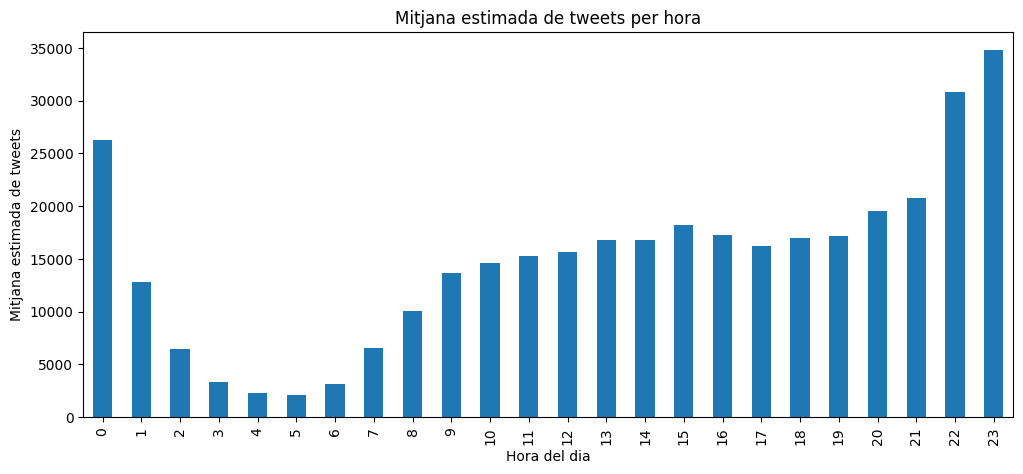

In [36]:
# Convertir el DataFrame de Spark a un DataFrame de pandas
tweets_hour_pd = tweets_hour.toPandas()

# Crear un gràfic de barres amb pandas
ax = tweets_hour_pd.plot(
    kind="bar",
    x="hour",
    y="tweets",
    figsize=(12, 5),
    legend=False,
    title="Mitjana estimada de tweets per hora"
)

# Etiquetes dels eixos
ax.set_xlabel("Hora del dia")
ax.set_ylabel("Mitjana estimada de tweets")

### Estratificat

En moltes ocasions el mostreig homogeni no és adequat ja que per la pròpia estructura de les dades determinats segments poden estar sobre-representades. Aquest és el cas que observem en els tweets on les grans àrees urbanes estan sobrerepresentades si ho comparem amb el volum de població. En aquesta activitat veurem com aplicar aquesta tècnica al dataset de tweets, per obtenir un mostreig que respecti la proporció de diputats per província.

A Espanya, el procés electoral assigna un volum de diputats a cada província que depèn de la població i d'un percentatge mínim assignat per llei. En el context Hive que hem creat prèviament (```hiveContext```) podem trobar una taula (```province_28a```) que conté informació sobre les circumscripcions electorals. Carregueu aquesta taula en una variable amb nom ```province```.

In [37]:
# Carregar la taula HIVE 'province_28a' dins d'un DataFrame de Spark
province = spark.table("province_28a")

province.limit(20).show()

+-----------+-----------+------------------+----------+---------+
|    capital|   province|              ccaa|population|diputados|
+-----------+-----------+------------------+----------+---------+
|     Teruel|     Teruel|            Aragón|     35691|        3|
|      Soria|      Soria|   Castilla y León|     39112|        2|
|    Segovia|    Segovia|   Castilla y León|     51683|        3|
|     Huesca|     Huesca|            Aragón|     52463|        3|
|     Cuenca|     Cuenca|Castilla-La Mancha|     54898|        3|
|      Ávila|      Ávila|   Castilla y León|     57697|        3|
|     Zamora|     Zamora|   Castilla y León|     61827|        3|
|Ciudad Real|Ciudad Real|Castilla-La Mancha|     74743|        5|
|   Palencia|   Palencia|   Castilla y León|     78629|        3|
| Pontevedra| Pontevedra|           Galicia|     82802|        7|
|     Toledo|     Toledo|Castilla-La Mancha|     84282|        6|
|Guadalajara|Guadalajara|Castilla-La Mancha|     84910|        3|
|      Ceu

In [38]:
assert province.count() == 52, "Incorrect answer"

Per fer un mostreig estratificat, primer hem de determinar la fracció que volem assignar a cada categoria. En aquest cas, volem una fracció que faci que la ràtio tweets per diputat sigui igual per a totes les capitals de província. Hem de tenir en compte que la precisió de la geolocalització a Twitter és normalment a nivell de ciutat. Per això, per evitar incrementar la complexitat de l'exercici, utilitzarem els tweets en capitals de província com a proxy dels tweets en tota la província.

### **Exercici 8**: Anàlisi de la Relació entre Tweets i Diputats per Província (*0.75 punts*)

El primer que heu de fer és crear una taula ```info_tweets_province``` que ha de contenir:
- ***capital:*** nom de la capital de província.
- ***tweets:*** nombre de tweets geolocalitzats en cada capital.
- ***diputats:*** diputats assignats a la província.
- ***ratio_tweets_diputat:*** nombre de tweets per diputat.

Heu d'ordenar la llista per ```ratio_tweets_diputado``` en ordre ascendent.

***Nota:*** Podeu realitzar aquest exercici de moltes maneres, probablement la més fàcil és utilitzar la taula ```tweets_place``` que heu generat en l'exercici 5. Recordeu com utilitzar el ```join()```.

In [39]:
# Crear la taula info_tweets_province combinant province i tweets_place
# Fem un INNER JOIN perquè només ens interessen les capitals que tenen
# tweets geolocalitzats associats
info_tweets_province = (
    province
    # Unir la informació de províncies amb els tweets per capital
    .join(
        tweets_place,
        province.capital == tweets_place.name,
        how="inner"
    )

    # Seleccionar les columnes finals que demana l'enunciat
    .select(
        # Nom de la capital de província
        province.capital.alias("capital"),

        # Nombre de tweets geolocalitzats en aquella capital
        tweets_place.tweets.alias("tweets"),

        # Nombre de diputats assignats a la província
        province.diputados.alias("diputados")
    )

    # Calcular la ràtio de tweets per diputat
    .withColumn(
        "ratio_tweets_diputado",
        F.col("tweets") / F.col("diputados")
    )

    # Ordenar de forma ascendent segons la ràtio
    .orderBy(F.col("ratio_tweets_diputado").asc())
)

# Mostrar una mostra del resultat
info_tweets_province.show(20, truncate=False)

[Stage 64:==================================================>       (7 + 1) / 8]

+----------------------+------+---------+---------------------+
|capital               |tweets|diputados|ratio_tweets_diputado|
+----------------------+------+---------+---------------------+
|Teruel                |8     |3        |2.6666666666666665   |
|Pontevedra            |29    |7        |4.142857142857143    |
|Zamora                |23    |3        |7.666666666666667    |
|Huesca                |26    |3        |8.666666666666666    |
|Segovia               |28    |3        |9.333333333333334    |
|Cádiz                 |108   |9        |12.0                 |
|Soria                 |25    |2        |12.5                 |
|Cuenca                |39    |3        |13.0                 |
|Ciudad Real           |67    |5        |13.4                 |
|Lugo                  |56    |4        |14.0                 |
|Pamplona              |77    |5        |15.4                 |
|Jaén                  |86    |5        |17.2                 |
|Guadalajara           |56    |3        

In [40]:
# VARIABLES DADAS
output = info_tweets_province.first()
maximum_ratio = floor(output.ratio_tweets_diputado * 100) / 100

In [41]:
# DO NOT USE THIS CELL

A continuació, necessitem un diccionari amb el nom ```ratios``` on cada capital de província és una clau i el seu valor associat és la fracció de tweets que anem a mostrejar. En aquest cas, el que volem és que la ràtio de tweets per cada diputat sigui similar per a cada capital de província.

Com que volem que el mostreig sigui el més gran possible i no volem que cap capital estigui infrarepresentada, la ràtio de tweets per diputat serà el valor més petit que podeu observar a la taula ```info_tweets_province```, que correspon a 2.66 tweets per diputat a Teruel. Teniu aquest valor guardat a la variable ```maximum_ratio```.

*Nota:* El mètode ```collectAsMap()``` transforma un PairRDD en un diccionari.

Finalment, genera una taula ```geo_tweets``` amb tots els tweets geolocalitzats. Ara ja estem en disposició de fer el mostreig estratificat per població. Per a això podeu utilitzar el mètode ```sampleBy()```. Utilitzeu 42 com a llavor del generador pseudoaleatori.

In [42]:
# Crear el diccionari 'ratios'
# Cada clau és una capital i cada valor és la fracció de mostreig
# necessària per aproximar la mateixa ràtio de tweets per diputat
ratios = (
    info_tweets_province
    .select("capital", "ratio_tweets_diputado")
    .rdd
    .map(
        lambda row: (
            row.capital,
            # Fracció de mostreig de la capital
            # La capital amb la ràtio mínima tindrà fracció 1.0
            # Les altres tindran una fracció menor que 1.0
            float(maximum_ratio / row.ratio_tweets_diputado)
        )
    )
    .collectAsMap()
)

# Mostrar una mostra del diccionari
print(list(ratios.items())[:10])

[('Teruel', 0.9975), ('Pontevedra', 0.6420689655172414), ('Zamora', 0.34695652173913044), ('Huesca', 0.30692307692307697), ('Segovia', 0.285), ('Cádiz', 0.22166666666666668), ('Soria', 0.21280000000000002), ('Cuenca', 0.20461538461538462), ('Ciudad Real', 0.19850746268656716), ('Lugo', 0.19)]


In [43]:
# Crear la taula amb tots els tweets geolocalitzats
geo_tweets = (
    tweets
    # Conservar només els tweets amb informació de lloc
    .filter(F.col("place").isNotNull())

    # Conservar només els tweets amb nom de lloc informat
    .filter(F.col("place.name").isNotNull())

    # Afegir una columna plana amb el nom de la capital/lloc
    .withColumn("capital", F.col("place.name"))
)

# Mostrar una mostra del resultat
geo_tweets.select("capital", "text").show(10, truncate=False)

+--------------------------+----------------------------------------------------------------------------------------------------------------------------------------------+
|capital                   |text                                                                                                                                          |
+--------------------------+----------------------------------------------------------------------------------------------------------------------------------------------+
|Barcelona                 |@nasholop @PSOE Nadie puede permitirse el "lujo" de no ir a votar. Es fundamental. Lo es siempre. No ir a votar en… https://t.co/7m7ZI7AwNH   |
|Palencia                  |@luttor007 @SextaNocheTV @Irene_Montero_ @PSOE Sabes Sumar?\nPues eso, Suma. https://t.co/P0mqEawdg4                                          |
|Murcia                    |@JORDIARCE Aquí se demuestra lo que yo te digo                                                                  

In [44]:
# Aplicar el mostreig estratificat per capital utilitzant el diccionari ratios
geo_tweets_sample = geo_tweets.sampleBy("capital", fractions=ratios, seed=42)

# Mostrar recompte abans i després del mostreig
print("Tweets geolocalitzats totals:", geo_tweets.count())
print("Tweets geolocalitzats mostrejats:", geo_tweets_sample.count())

Tweets geolocalitzats totals: 44477


[Stage 84:==================================================>       (7 + 1) / 8]

Tweets geolocalitzats mostrejats: 849


In [45]:
# DO NOT USE THIS CELL

## Introducció a les dades relacionals

El fet de treballar amb una base de dades que conté informació generada en una xarxa social ens permet introduir el concepte de dades relacionals. Podem definir dades relacionals com aquelles en què existeixen relacions entre les entitats que constitueixen la base de dades. Si aquestes relacions són binàries, relacions 1 a 1, podem representar les relacions com un graf compost per un conjunt de vèrtexs $\mathcal{V}$ i un conjunt d'arestes $\mathcal{E}$ que els relacionen.

En el cas de grafs que emergeixen de manera orgànica, aquest tipus d'estructura va més enllà dels grafs regulars que segurament coneixeu. Aquest tipus d'estructures es coneixen com a [xarxes complexes](https://ca.wikipedia.org/wiki/Xarxa_complexa). L'estudi de l'estructura i dinàmiques d'aquest tipus de xarxes ha contribuït a importants resultats en camps tan dispars com la física, la sociologia, l'ecologia o la medicina.

![complex_network](https://images.squarespace-cdn.com/content/5150aec6e4b0e340ec52710a/1364574727391-XVOFAB9P6GHKTDAH6QTA/lastfm_800_graph_white.png?content-type=image%2Fpng)

En aquesta última part de la pràctica treballarem amb aquest tipus de dades. En concret modelarem una de les possibles relacions presents en el dataset, la xarxa de retweets.

#### Construcció de l'edgelist

El primer que se us demana és que genereu la xarxa. Hi ha diverses maneres de representar una xarxa complexa, per exemple, si estiguéssiu interessats a treballar-hi des del punt de vista teòric, la manera més habitual de representar-les és utilitzant una [matriu d'adjacència](https://ca.wikipedia.org/wiki/Matriu_d%27adjacència). En aquesta pràctica ens centrarem en l'aspecte computacional, una de les maneres més eficients (computacionalment parlant) de representar una xarxa és mitjançant la seva [*edge list*](https://en.wikipedia.org/wiki/Edge_list), una taula que especifica la relació a parelles entre les entitats.

Les relacions poden ser bidireccionals o direccionals i tenir algun pes assignat o no (weighted or unweighted). En el cas que ens ocupa, estem parlant d'una xarxa dirigida, un usuari retuiteja a un altre, i podem pensar-la tenint en compte quantes vegades això ha passat.

#### Centralitat de grau

Un dels descriptors més comuns en l'anàlisi de xarxes és el grau. El grau quantifica quantes arestes estan connectades a cada vèrtex~s~. En el cas de xarxes dirigides com la que acabem de crear aquest descriptor està descompost en el:
- **in degree**: quantes arestes apunten al node
- **out degree**: quantes arestes surten del node

Si fas un rànquing d'aquests valors obtindràs una mesura de centralitat, la [centralitat de grau](https://en.wikipedia.org/wiki/Centrality#Degree_centrality), de cadascun dels nodes.

### **Exercici 9**: Anàlisi d'Interaccions de Retweets i Graus d'Usuari (*0.5 punts*)

A partir d'una mostra homogènia de l'1% dels tweets, amb la llavor 42 per garantir la reproductibilitat, realitza una anàlisi de les interaccions de retweets entre usuaris a la xarxa social.

**Esquema**
```Python
seed = 42
sample = tweets.<FILL IN>
```
Crea una taula ```edgelist``` amb la següent informació:
- ***src:*** usuari que retuiteja
- ***dst:*** usuari que és retuitejat
- ***weight:*** nombre de vegades que un usuari retuiteja a un altre.

Filtra el resultat perquè contingui només les relacions amb un weight igual o superior a dos.

A continuació, genera una taula `outDegree` amb la informació:
- ***screen_name:*** nom de l'usuari.
- ***outDegree:*** out degree del node.

Ordena la taula per out degree en ordre descendent.

Se us demana ara que genereu una taula `inDegree` amb la informació:
- ***screen_name:*** nom de l'usuari.
- ***inDegree:*** in degree del node.

Ordena la taula per in degree en ordre descendent.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Exercici 9: Interpretació del dataset per construir la xarxa de retweets</strong><br><br>

<strong>Interpretacions utilitzades:</strong>
<table border="1" cellpadding="5" cellspacing="0" style="border-collapse: collapse; margin: 10px 0;">
    <tr style="background-color: #7C9DBF; color: white;">
        <th>Element</th>
        <th>Interpretació aplicada</th>
    </tr>
    <tr>
        <td><code>user.screen_name</code></td>
        <td>S'interpreta com l'usuari que publica el tweet observat. Si el tweet és un retweet, aquest camp correspon a l'usuari que <strong>retuiteja</strong>.</td>
    </tr>
    <tr>
        <td><code>retweeted_status.user.screen_name</code></td>
        <td>S'interpreta com l'usuari autor del tweet original que ha estat retuitejat, és a dir, l'usuari que <strong>és retuitejat</strong>.</td>
    </tr>
    <tr>
        <td><code>src</code></td>
        <td>Node origen de l'aresta dirigida. Representa l'usuari que fa el retweet.</td>
    </tr>
    <tr>
        <td><code>dst</code></td>
        <td>Node destí de l'aresta dirigida. Representa l'usuari el contingut del qual és retuitejat.</td>
    </tr>
    <tr>
        <td><code>weight</code></td>
        <td>Nombre de vegades que un usuari <code>src</code> ha retuitejat un usuari <code>dst</code>. Es calcula comptant repeticions de la mateixa parella <code>(src, dst)</code>.</td>
    </tr>
    <tr>
        <td><code>outDegree</code></td>
        <td>Nombre d'arestes sortints d'un node després de filtrar per <code>weight &gt;= 2</code>. S'interpreta com el nombre d'usuaris diferents que un usuari ha retuitejat dins la xarxa filtrada.</td>
    </tr>
    <tr>
        <td><code>inDegree</code></td>
        <td>Nombre d'arestes entrants d'un node després de filtrar per <code>weight &gt;= 2</code>. S'interpreta com el nombre d'usuaris diferents que han retuitejat aquest usuari dins la xarxa filtrada.</td>
    </tr>
</table>

<strong>Anàlisi:</strong><br><br>

<strong>1. Xarxa dirigida:</strong> En aquest exercici es modela una xarxa de retweets com un graf dirigit, ja que la relació no és simètrica: un usuari retuiteja un altre, però no necessàriament a l'inrevés. Per això l'aresta es defineix des de <code>src</code> cap a <code>dst</code>.<br><br>

<strong>2. Construcció de l'edgelist:</strong> La taula <code>edgelist</code> no representa tweets individuals, sinó relacions agregades entre parelles d'usuaris. Quan una mateixa relació <code>src → dst</code> apareix diverses vegades, aquestes repeticions es resumeixen en un únic registre amb un valor <code>weight</code> que indica la intensitat de la relació.<br><br>

<strong>3. Filtre per pes:</strong> L'enunciat demana conservar només les relacions amb <code>weight</code> igual o superior a 2. Això implica que la xarxa final exclou interaccions puntuals i es concentra en relacions de retweet més consistents o repetides.<br><br>

<strong>4. Interpretació dels graus:</strong> En aquesta resolució s'interpreta que <code>outDegree</code> i <code>inDegree</code> mesuren el nombre d'arestes connectades a cada node, no la suma dels pesos. Per tant, els graus indiquen connectivitat estructural dins la xarxa, mentre que <code>weight</code> reflecteix la intensitat de cada relació concreta.<br><br>

<strong>5. Conclusió:</strong> Aquesta interpretació permet construir una representació coherent de la xarxa de retweets a partir del dataset disponible. Es distingeix clarament entre qui genera el retweet i qui el rep, es resumeixen les interaccions repetides amb <code>weight</code> i es calculen els graus sobre la xarxa ja filtrada, obtenint així una visió estructural de les interaccions entre usuaris.
</div>

In [46]:
# Importar les funcions necessàries de Spark SQL
from pyspark.sql import functions as F

# Definir la llavor i la fracció de mostreig
seed = 42
fraction = 0.01

# Generar una mostra homogènia de l'1% a partir de la taula completa de tweets
sample = tweets.sample(withReplacement=False, fraction=fraction, seed=seed)

# Mostrar quants tweets hi ha a la mostra
print("Nombre de tweets a la mostra:", sample.count())

Nombre de tweets a la mostra: 64063


In [47]:
# Crear l'edgelist de la xarxa de retweets
# Cada aresta representa que un usuari (src) retuiteja un altre usuari (dst)
edgelist = (
    sample
    # Conservar només els tweets que són realment retweets
    .filter(F.col("retweeted_status").isNotNull())

    # Assegurar que existeix l'usuari que retuiteja
    .filter(F.col("user.screen_name").isNotNull())

    # Assegurar que existeix l'usuari original retuitejat
    .filter(F.col("retweeted_status.user.screen_name").isNotNull())

    # Agrupar per parella (src, dst)
    .groupBy(
        F.col("user.screen_name").alias("src"),
        F.col("retweeted_status.user.screen_name").alias("dst")
    )

    # Comptar quantes vegades es repeteix cada relació src -> dst
    .count()

    # Reanomenar la columna count a weight
    .withColumnRenamed("count", "weight")

    # Filtrar només les relacions amb pes igual o superior a 2
    .filter(F.col("weight") >= 2)
)

# Registrar la taula temporal per si cal reutilitzar-la després
edgelist.createOrReplaceTempView("edgelist")

# Mostrar una mostra del resultat
edgelist.show(20, truncate=False)

[Stage 90:==================================================>       (7 + 1) / 8]

+---------------+---------------+------+
|src            |dst            |weight|
+---------------+---------------+------+
|Socialista60   |Nachoanon      |2     |
|TopTradingBolsa|ahorapodemos   |3     |
|lajusticieracat|gabrielrufian  |2     |
|manolivi64     |protestona1    |2     |
|maynake84      |Pacma_Madrid   |2     |
|margaritafontr |josepalay      |2     |
|Antonio84960717|ivanedlm       |2     |
|EloyValMar     |CiudadanosCs   |2     |
|Pdemocratacat  |JuntsXCat      |5     |
|daniiglesias_cs|CiudadanosCs   |2     |
|nriamig        |ABalagu        |2     |
|puric2         |Manololorente  |2     |
|Losliberales181|vox_es         |2     |
|RaulRuizDelgado|vox_es         |2     |
|carmela87874604|Pablo_Iglesias_|2     |
|towertattoo    |iescolar       |2     |
|pallaron12     |Ramapetrea     |2     |
|BillSpe46965090|Tampm_Puertos  |2     |
|joseracostas   |voxnoticias_es |2     |
|Ref1Oct17      |partit_pirata  |2     |
+---------------+---------------+------+
only showing top

In [48]:
# Crear la taula outDegree
# L'out degree compta quantes arestes surten de cada usuari,
# és a dir, quants usuaris diferents ha retuitejat
outDegree = (
    edgelist
    # Agrupar per usuari origen
    .groupBy("src")

    # Comptar quantes arestes surten de cada usuari
    .count()

    # Reanomenar les columnes segons l'enunciat
    .withColumnRenamed("src", "screen_name")
    .withColumnRenamed("count", "outDegree")

    # Ordenar de forma descendent per outDegree
    .orderBy(F.col("outDegree").desc())
)

# Registrar la taula temporal
outDegree.createOrReplaceTempView("outDegree")

# Mostrar una mostra del resultat
outDegree.show(20, truncate=False)

[Stage 93:==================================================>       (7 + 1) / 8]

+---------------+---------+
|screen_name    |outDegree|
+---------------+---------+
|soniapillado70 |3        |
|carrasquem     |2        |
|Zibelinam      |2        |
|CsCartagena    |2        |
|TorrijosMari   |2        |
|Perona10690463 |2        |
|miguelgutiperez|2        |
|mariaje1956    |2        |
|rsarille4      |2        |
|FRANCIS67590251|2        |
|mariamg2009    |1        |
|MaraMato2      |1        |
|Ragachica      |1        |
|valores_primero|1        |
|JosepTraveler  |1        |
|saribes        |1        |
|juntsxcatGracia|1        |
|ptl19670507    |1        |
|towertattoo    |1        |
|fondonti       |1        |
+---------------+---------+
only showing top 20 rows



In [49]:
# Crear la taula inDegree
# L'in degree compta quantes arestes entren a cada usuari,
# és a dir, quants usuaris diferents l'han retuitejat
inDegree = (
    edgelist
    # Agrupar per usuari destí
    .groupBy("dst")

    # Comptar quantes arestes entren a cada usuari
    .count()

    # Reanomenar les columnes segons l'enunciat
    .withColumnRenamed("dst", "screen_name")
    .withColumnRenamed("count", "inDegree")

    # Ordenar de forma descendent per inDegree
    .orderBy(F.col("inDegree").desc())
)

# Registrar la taula temporal
inDegree.createOrReplaceTempView("inDegree")

# Mostrar una mostra del resultat
inDegree.show(20, truncate=False)

[Stage 99:==================================================>       (7 + 1) / 8]

+---------------+--------+
|screen_name    |inDegree|
+---------------+--------+
|PSOE           |44      |
|CiudadanosCs   |36      |
|vox_es         |32      |
|ahorapodemos   |29      |
|populares      |17      |
|AlbanoDante76  |9       |
|Santi_ABASCAL  |8       |
|ivanedlm       |7       |
|Pablo_Iglesias_|7       |
|Front_Republica|7       |
|boye_g         |6       |
|pablocasado_   |6       |
|protestona1    |6       |
|JuntsXCat      |6       |
|iescolar       |5       |
|rosadiezglez   |4       |
|CastigadorY    |4       |
|KRLS           |4       |
|voxnoticias_es |4       |
|JonInarritu    |4       |
+---------------+--------+
only showing top 20 rows



In [50]:
# Mostrar l'esquema de l'edgelist
edgelist.printSchema()

# Comptar quantes relacions hi ha després del filtre weight >= 2
print("Nombre d'arestes a l'edgelist:", edgelist.count())

root
 |-- src: string (nullable = true)
 |-- dst: string (nullable = true)
 |-- weight: long (nullable = false)



[Stage 105:=================================================>       (7 + 1) / 8]

Nombre d'arestes a l'edgelist: 469


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Exercici 9: Anàlisi final de la xarxa de retweets</strong><br><br>

<strong>Resultats obtinguts:</strong>
<table border="1" cellpadding="5" cellspacing="0" style="border-collapse: collapse; margin: 10px 0;">
    <tr style="background-color: #7C9DBF; color: white;">
        <th>Element</th>
        <th>Resultat</th>
    </tr>
    <tr>
        <td>Estructura de la taula <code>edgelist</code></td>
        <td><code>src</code>, <code>dst</code>, <code>weight</code></td>
    </tr>
    <tr>
        <td>Tipus de relació</td>
        <td>Xarxa dirigida de retweets</td>
    </tr>
    <tr>
        <td>Filtre aplicat</td>
        <td><code>weight &gt;= 2</code></td>
    </tr>
    <tr>
        <td>Nombre final d'arestes</td>
        <td><strong>469</strong></td>
    </tr>
</table>

<strong>Anàlisi:</strong><br><br>

<strong>1. Construcció de la xarxa:</strong> La taula <code>edgelist</code> representa una xarxa dirigida on <code>src</code> és l'usuari que fa el retweet i <code>dst</code> és l'usuari que rep el retweet. El camp <code>weight</code> recull quantes vegades es repeteix una mateixa relació <code>src → dst</code>, de manera que no es treballa amb tweets individuals sinó amb interaccions agregades entre usuaris.<br><br>

<strong>2. Filtre per pes:</strong> En conservar només les relacions amb <code>weight &gt;= 2</code>, s'eliminen les interaccions puntuals i es mantenen únicament aquelles connexions que mostren una certa recurrència. Això permet centrar l'anàlisi en relacions més consistents dins la xarxa de retweets.<br><br>

<strong>3. Interpretació del recompte:</strong> El resultat final de <strong>469 arestes</strong> indica que, després del mostreig homogeni de l'1% i del filtratge per pes mínim, la xarxa manté un conjunt rellevant de connexions entre usuaris. Aquest valor és coherent amb una representació més compacta de la xarxa, on només es conserven les relacions repetides.<br><br>

<strong>4. Centralitat de grau:</strong> A partir d'aquesta xarxa, les taules <code>outDegree</code> i <code>inDegree</code> permeten estudiar la centralitat de grau dels usuaris. L'<code>outDegree</code> mesura quants usuaris diferents ha retuitejat cada node, mentre que l'<code>inDegree</code> mesura quants usuaris diferents han retuitejat aquell node. Això permet identificar perfils més actius en la difusió de contingut i perfils amb més capacitat d'atracció dins la xarxa.<br><br>

<strong>5. Conclusió:</strong> La construcció de l'<code>edgelist</code> ha permès transformar la informació de retweets en una xarxa dirigida interpretable des del punt de vista relacional. El filtre per <code>weight &gt;= 2</code> redueix el soroll i facilita l'estudi de les interaccions més significatives. En conjunt, aquest exercici mostra com un dataset de tweets es pot convertir en una estructura de graf útil per analitzar patrons de centralitat i difusió d'informació.
</div>

In [51]:
# DO NOT USE THIS CELL

### **Exercici 10**: Distribució del Grau de Sortida en una Xarxa de Retweets (*0.5 punts*)

A partir d'una mostra de l'1% dels tweets, amb una llavor de 42 per assegurar la reproductibilitat, realitza una anàlisi bàsica de la xarxa de retweets. El teu objectiu és calcular i mostrar la distribució de graus dels usuaris en la xarxa de retweets.

Per a això, segueix aquests passos:

- Crea una taula de Edgelist: Defineix una taula `edgelist` que contingui les relacions de retweet entre usuaris, on cada fila representa un retweet realitzat d'un usuari a un altre.

- Calcula el Grau de Sortida (Out-Degree): Determina quants retweets ha realitzat cada usuari (és a dir, el nombre d'usuaris als quals cada usuari ha retuitejat). Anomena aquesta variable `outDegree`.

- Obté la Distribució de Grau de Sortida: Crea una taula `outDegree_distribution` que mostri quants usuaris tenen un determinat nombre de retweets realitzats. Ordena els resultats pel grau de sortida.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Exercici 10: Interpretació aplicada per calcular la distribució del grau de sortida</strong><br><br>

<strong>Interpretacions utilitzades:</strong>
<ul>
    <li><strong>Mostra utilitzada:</strong> es genera una mostra homogènia de l'1% dels tweets amb <code>seed = 42</code> per garantir la reproductibilitat.</li>
    <li><strong>Xarxa dirigida:</strong> es modela una xarxa de retweets on cada aresta va des de l'usuari que retuiteja cap a l'usuari retuitejat.</li>
    <li><strong><code>src</code>:</strong> s'interpreta com l'usuari que fa el retweet (<code>user.screen_name</code>).</li>
    <li><strong><code>dst</code>:</strong> s'interpreta com l'usuari autor del tweet original retuitejat (<code>retweeted_status.user.screen_name</code>).</li>
    <li><strong>Edgelist:</strong> per calcular el grau de sortida, es considera una aresta per cada retweet real <code>(src, dst)</code>.</li>
    <li><strong><code>outDegree</code>:</strong> es defineix com el nombre d'usuaris diferents als quals un usuari ha retuitejat, és a dir, el nombre d'arestes sortints del node.</li>
    <li><strong><code>outDegree_distribution</code>:</strong> mostra quants usuaris tenen un determinat valor de grau de sortida.</li>
</ul>


In [52]:
# Importar les funcions necessàries de Spark SQL
from pyspark.sql import functions as F

# Definir la llavor i la fracció de mostreig
seed = 42
fraction = 0.01

# Generar una mostra homogènia de l'1% dels tweets
# Si ja tens la variable sample creada de l'exercici anterior, aquesta línia es pot ometre
sample = tweets.sample(withReplacement=False, fraction=fraction, seed=seed)

# Crear la taula edgelist de la xarxa de retweets
# Cada aresta representa una retweet real entre un usuari que retuiteja (src)
# i un usuari que és retuitejat (dst)
edgelist = (
    sample
    # Conservar només els tweets que són retweets
    .filter(F.col("retweeted_status").isNotNull())

    # Exigir que existeixi el nom de l'usuari que retuiteja
    .filter(F.col("user.screen_name").isNotNull())

    # Exigir que existeixi el nom de l'usuari original retuitejat
    .filter(F.col("retweeted_status.user.screen_name").isNotNull())

    # Seleccionar les dues columnes que defineixen l'aresta
    .select(
        F.col("user.screen_name").alias("src"),
        F.col("retweeted_status.user.screen_name").alias("dst")
    )

)

# Mostrar una mostra de l'edgelist
edgelist.show(20, truncate=False)

# Calcular el grau de sortida (out-degree) de cada usuari
# Això compta quants usuaris diferents ha retuitejat cada node
outDegree = (
    edgelist
    # Agrupar per node origen
    .groupBy("src")

    # Comptar quantes arestes sortints té cada usuari
    .count()

    # Reanomenar les columnes segons l'enunciat
    .withColumnRenamed("src", "screen_name")
    .withColumnRenamed("count", "outDegree")
)

# Mostrar una mostra de la taula outDegree
outDegree.show(20, truncate=False)

# Calcular la distribució del grau de sortida
# Això indica quants usuaris tenen cada valor possible de outDegree
outDegree_distribution = (
    outDegree
    # Agrupar pel valor del grau de sortida
    .groupBy("outDegree")

    # Comptar quants usuaris tenen aquell outDegree
    .count()

    # Reanomenar la columna count perquè sigui més descriptiva
    .withColumnRenamed("count", "users")

    # Ordenar els resultats pel grau de sortida
    .orderBy(F.col("outDegree").asc())
)

# Mostrar la distribució final
outDegree_distribution.show(20, truncate=False)

+---------------+---------------+
|src            |dst            |
+---------------+---------------+
|magdugui       |EsterMunoz85   |
|manuraortiz    |PSOE           |
|Bgo13          |abarceloh25    |
|nukabaro       |Pablo_Iglesias_|
|Karvayal       |revistamongolia|
|tavoctz        |olga_alman     |
|ademaroni      |ivanedlm       |
|Carlos311266   |ConsuorF       |
|ronfraba       |pontevedrapp   |
|bertavane      |FrayJosepho    |
|19942011ernesto|fjosealcaraz   |
|mikeldur       |socialistavasco|
|CsBarbadas     |CsOurenseProv  |
|Pacoescuderoo  |marle_ledo     |
|eduardmotos    |aitorbengoam   |
|Marahersa      |PSOELaPalma    |
|miguelgutiperez|jasalo54       |
|jorgitofil     |gabrielrufian  |
|Lluisahueso    |sedlr_         |
|soyelhansa1979 |josecdiez      |
+---------------+---------------+
only showing top 20 rows



+---------------+---------+
|screen_name    |outDegree|
+---------------+---------+
|iresaurio      |2        |
|snuezd         |3        |
|vinoteco2      |2        |
|cagacol        |1        |
|xavierpueyo    |1        |
|VpVera17       |2        |
|PolBenMon      |1        |
|MariaMartos98  |1        |
|Anasalbcn      |3        |
|WALTONJUAN     |1        |
|republica3aviva|5        |
|pereirasergioba|8        |
|j_breda_gisbert|2        |
|mariamg2009    |3        |
|SirKrispulo    |4        |
|wZRBM2GqBJNVRkB|1        |
|SvartiKraka    |1        |
|RaqueeeelJ     |1        |
|Mattrioska     |1        |
|josepgomezg    |1        |
+---------------+---------+
only showing top 20 rows



[Stage 115:=================================================>       (7 + 1) / 8]

+---------+-----+
|outDegree|users|
+---------+-----+
|1        |30446|
|2        |4080 |
|3        |1391 |
|4        |614  |
|5        |332  |
|6        |178  |
|7        |94   |
|8        |67   |
|9        |38   |
|10       |31   |
|11       |15   |
|12       |21   |
|13       |8    |
|14       |5    |
|15       |2    |
|16       |5    |
|17       |5    |
|18       |2    |
|19       |2    |
|20       |2    |
+---------+-----+
only showing top 20 rows



In [53]:
# DO NOT USE THIS CELL

### **Exercici 11**: Preguntes teòriques (*2.5 punts*)

Durant l'entrevista final amb cada grup, que es realitzarà mitjançant videotrucada, es revisarà breument la pràctica realitzada.

A la darrera part de l'entrevista es plantejaran 4 preguntes teòriques relacionades amb els continguts de la pràctica i del temari vist fins ara (Des del mòdul 1, fins al mòdul 4).

- Cada pregunta tindrà una puntuació de 0,625 punts.

- Les preguntes es respondran oralment durant l'entrevista.

- Es valorarà la comprensió dels conceptes teòrics i la capacitat d'explicar-los amb claredat.